## Batticaloa, Sri Lanka

This notebook utilises the PyGMTSAR ecosystem to transform stacks of Sentinel-1 Synthetic Aperture Radar (SAR) imagery into actionable geodetic data on subsidence.

The PyGMTSAR InSAR library, Geomed3D Geophysical Inversion Library, N-Cube 3D/4D GIS Data Visualization, among others used in this notebook, are open-source projects developed by Alexey Pechnikov. The original script can be found at https://colab.research.google.com/drive/1ipiQGbvUF8duzjZER8v-_R48DSpSmgvQ?usp=sharing.

You can support Alexey Pechnikov's work on [Patreon](https://www.patreon.com/pechnikov), where he share updates on his projects, publications, use cases, examples, and other useful information. For research and development services and support, please visit his profile on the freelance platform [Upwork](https://www.upwork.com).

© Alexey Pechnikov, 2024

$\large\color{blue}{\text{Hint: Use menu Cell} \to \text{Run All or Runtime} \to \text{Complete All or Runtime} \to \text{Run All}}$
$\large\color{blue}{\text{(depending of your localization settings) to execute the entire notebook}}$

## Google Colab Installation

Install PyGMTSAR and required GMTSAR binaries (including SNAPHU)

In [ ]:
import sys
print(sys.version)
for m in ['vtk', 'pyvista', 'panel', 'holoviews']:
    try:
        mod = __import__(m)
        print(f'{m:10s} OK   {getattr(mod, "__version__", "?")}')
    except Exception as e:
        print(f'{m:10s} FAIL {type(e).__name__}: {e}')

3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
vtk        OK   9.7.0
pyvista    OK   0.49.0
panel      OK   1.9.4
holoviews  OK   1.23.2


In [ ]:
from pygmtsar import S1, Stack, ASF, Tiles
import asf_search, subprocess, shutil
print('pygmtsar   ', __import__('pygmtsar').__version__)
print('asf_search ', asf_search.__version__)
print('gmtsar bin ', shutil.which('p2p_S1_TOPS.csh') or 'NOT ON PATH')

pygmtsar    2025.4.8.post1
asf_search  13.0.1
gmtsar bin  NOT ON PATH


In [ ]:
import os, shutil

GMTSAR_BIN = '/usr/local/GMTSAR/bin'

if os.path.isdir(GMTSAR_BIN):
    print(f'GMTSAR on disk: {len(os.listdir(GMTSAR_BIN))} files in {GMTSAR_BIN}')
else:
    print(f'GMTSAR NOT on disk at {GMTSAR_BIN} — install script needs re-running')

if GMTSAR_BIN not in os.environ['PATH']:
    os.environ['PATH'] += ':' + GMTSAR_BIN
    print('PATH updated')

for exe in ['make_s1a_tops', 'esarp', 'phasediff', 'xcorr', 'snaphu', 'gmt']:
    print(f'  {exe:16s} {shutil.which(exe) or "MISSING"}')

GMTSAR on disk: 164 files in /usr/local/GMTSAR/bin
PATH updated
  make_s1a_tops    /usr/local/GMTSAR/bin/make_s1a_tops
  esarp            /usr/local/GMTSAR/bin/esarp
  phasediff        /usr/local/GMTSAR/bin/phasediff
  xcorr            /usr/local/GMTSAR/bin/xcorr
  snaphu           /usr/local/GMTSAR/bin/snaphu
  gmt              /usr/bin/gmt


In [ ]:
import platform, sys, os
if 'google.colab' in sys.modules:
    # install PyGMTSAR stable version from PyPI
    !{sys.executable} -m pip install -q pygmtsar
    # alternatively, nstall PyGMTSAR development version from GitHub
    #!{sys.executable} -m pip install -Uq git+https://github.com/mobigroup/gmtsar.git@pygmtsar2#subdirectory=pygmtsar
    # use PyGMTSAR Google Colab installation script to install binary dependencies
    # script URL: https://github.com/AlexeyPechnikov/pygmtsar/blob/pygmtsar2/pygmtsar/pygmtsar/data/google_colab.sh
    import importlib.resources as resources
    with resources.as_file(resources.files('pygmtsar.data') / 'google_colab.sh') as google_colab_script_filename:
        !sh {google_colab_script_filename}
    # enable custom widget manager as required by recent Google Colab updates
    from google.colab import output
    output.enable_custom_widget_manager()
    # initialize virtual framebuffer for interactive 3D visualization; required for headless environments
    import xvfbwrapper
    display = xvfbwrapper.Xvfb(width=800, height=600)
    display.start()

# specify GMTSAR installation path
PATH = os.environ['PATH']
if PATH.find('GMTSAR') == -1:
    PATH = os.environ['PATH'] + ':/usr/local/GMTSAR/bin/'
    %env PATH {PATH}

# display PyGMTSAR version
from pygmtsar import __version__
__version__

'2025.4.8.post1'

## Load and Setup Python Modules

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import json
from dask.distributed import Client
import dask
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# plotting modules
import pyvista as pv
# magic trick for white background
pv.set_plot_theme("document")
import panel
panel.extension(comms='ipywidgets')
panel.extension('vtk')
from contextlib import contextmanager
import matplotlib.pyplot as plt
@contextmanager
def mpl_settings(settings):
    original_settings = {k: plt.rcParams[k] for k in settings}
    plt.rcParams.update(settings)
    yield
    plt.rcParams.update(original_settings)
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.titlesize'] = 24
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
%matplotlib inline

In [ ]:
# define Pandas display settings
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

In [ ]:
from pygmtsar import S1, Stack, tqdm_dask, ASF, Tiles, XYZTiles

# recent Google Colab changes in early September 2025 broke Dask+Xarray NetCDF multithedded processing (again)
# workaround below disables multitheading when it does not work, degrading performance and increasing RAM usage.
if 'google.colab' in sys.modules:
    methods = {
        "load_dem":  "synchronous",
        "save_cube": "compute",
        "save_stack":"compute",
        "compute_interferogram_singlelook": "synchronous"
    }
    for m, kind in methods.items():
        if not hasattr(Stack, f"_{m}"):
            setattr(Stack, f"_{m}", getattr(Stack, m))
        def _make_wrapper(name, kind):
            orig = getattr(Stack, f"_{name}")
            if kind == "synchronous":
                def _wrapper(self, *args, **kwargs):
                    with dask.config.set(scheduler="synchronous"):
                        return orig(self, *args, **kwargs)
                return _wrapper
            elif kind == "compute":
                def _wrapper(self, *args, **kwargs):
                    if args:
                        return orig(self, args[0].compute() if hasattr(args[0], "compute") else args[0], *args[1:], **kwargs)
                    return orig(self, **kwargs)
                return _wrapper
            else:
                raise NotImplementedError(f"Unknown wrapper kind: {kind}")
        setattr(Stack, m, _make_wrapper(m, kind))

## Define Sentinel-1 SLC Scenes and Processing Parameters

### Descending Orbit Configuration

Configuration below is deliberately **identical between the ascending and
descending notebooks** except for `ORBIT`, `REFERENCE` and `BURSTS`. The AOI,
the buffer, the reference point and the analysis window must match across
orbits, otherwise the two solutions sit on different datums and cannot be
cross-validated or decomposed into vertical motion.


In [ ]:
# ============================================================
# SITE CONFIGURATION - keep identical across both orbit notebooks
# ============================================================

SITE      = 'batticaloa'
ORBIT     = 'A'          # 'A' ascending / 'D' descending
SUBSWATH  = 2
REFERENCE = '2023-06-22'   # mid-stack scene: better coregistration than
                            # the first scene, and it sits inside the common
                            # analysis window shared with the other orbit

# --- Common analysis window ---------------------------------------------
# The ascending stack starts 2014-12 and the descending 2016-12. Velocities
# over different periods are not comparable, so both are truncated to the
# later start date.
ANALYSIS_START = '2020-01-01'
ANALYSIS_END   = '2025-12-31'

# --- Area of interest, shared by both orbits ----------------------------
# (W, S, E, N). Union of the two AOIs used in the original notebooks, which
# covered different ground.
AOI_BOUNDS = dict(
    batticaloa=(81.6784, 7.7071, 81.7048, 7.7431),
    # jaffna=(...),
    # chilaw=(...),
    # puttalam=(...),
)

BUFFER = 0.025   # degrees, ~2.8 km. Applied in BOTH notebooks so that the
                 # polynomial trend fit has room and unwrapping edge effects
                 # fall outside the reporting area. Results are reported only
                 # within AOI.buffer(-BUFFER).

# --- Points of interest, shared by both orbits --------------------------
# The reference point must be the SAME pixel in both orbits. InSAR
# displacement is relative to this pixel.
POI_COORDS  = dict(batticaloa=(81.7038677619181, 7.730543000075244))
POI0_COORDS = dict(batticaloa=(81.6971816637685, 7.7382461786477705))

# --- Fixed plotting scales so all four lagoons are comparable -----------
VEL_VMIN, VEL_VMAX   = -30, 30     # mm/yr
DISP_VMIN, DISP_VMAX = -100, 100   # mm
CMAP = 'RdBu_r'                    # diverging and zero-centred; 'turbo' is
                                   # perceptually non-uniform and misleading
                                   # for signed deformation


Burst search for this site. Replace the polygon with the AOI bounds above:

`https://search.asf.alaska.edu/#/?dataset=SENTINEL-1%20BURSTS&polarizations=VV&productTypes=BURST`

The original template's search URL pointed at Los Angeles and has been removed.


In [ ]:
# SCENES = """
# S1A_IW_SLC__1SDV_20211220T135243_20211220T135311_041093_04E1C6_571D
# S1A_IW_SLC__1SDV_20211208T135244_20211208T135312_040918_04DBF1_5BB3
# S1A_IW_SLC__1SDV_20211126T135244_20211126T135312_040743_04D5D8_F7BC
# S1A_IW_SLC__1SDV_20211114T135245_20211114T135313_040568_04CFD7_582A
# S1A_IW_SLC__1SDV_20211102T135245_20211102T135313_040393_04C9B8_06BA
# S1A_IW_SLC__1SDV_20211021T135246_20211021T135313_040218_04C3A1_AC92
# S1A_IW_SLC__1SDV_20211009T135246_20211009T135313_040043_04BD89_8A1C
# S1A_IW_SLC__1SDV_20210927T135246_20210927T135313_039868_04B77E_080A
# S1A_IW_SLC__1SDV_20210915T135245_20210915T135312_039693_04B182_B51B
# S1A_IW_SLC__1SDV_20210903T135245_20210903T135312_039518_04AB89_6CBC
# S1A_IW_SLC__1SDV_20210822T135244_20210822T135311_039343_04A583_7922
# S1A_IW_SLC__1SDV_20210810T135244_20210810T135311_039168_049F83_A317
# S1A_IW_SLC__1SDV_20210729T135243_20210729T135310_038993_0499C7_1A1B
# S1A_IW_SLC__1SDV_20210717T135242_20210717T135309_038818_049496_0ABE
# S1A_IW_SLC__1SDV_20210705T135242_20210705T135309_038643_048F59_0F30
# S1A_IW_SLC__1SDV_20210623T135241_20210623T135308_038468_048A0E_7E2B
# S1A_IW_SLC__1SDV_20210611T135240_20210611T135307_038293_0484D8_D775
# S1A_IW_SLC__1SDV_20210530T135240_20210530T135306_038118_047FAA_A70D
# S1A_IW_SLC__1SDV_20210518T135239_20210518T135306_037943_047A68_660C
# S1A_IW_SLC__1SDV_20210506T135238_20210506T135305_037768_047520_2C81
# S1A_IW_SLC__1SDV_20210424T135238_20210424T135305_037593_046F1A_82DC
# S1A_IW_SLC__1SDV_20210412T135237_20210412T135304_037418_046911_7DB6
# S1A_IW_SLC__1SDV_20210331T135237_20210331T135304_037243_046307_91F1
# S1A_IW_SLC__1SDV_20210319T135236_20210319T135303_037068_045CFB_34F9
# S1A_IW_SLC__1SDV_20210307T135236_20210307T135303_036893_0456E2_0C1D
# S1A_IW_SLC__1SDV_20210223T135236_20210223T135303_036718_0450C6_883C
# S1A_IW_SLC__1SDV_20210211T135237_20210211T135304_036543_044AAA_DAE0
# S1A_IW_SLC__1SDV_20210130T135237_20210130T135304_036368_04449D_30E3
# S1A_IW_SLC__1SDV_20210118T135237_20210118T135304_036193_043E88_5815
# S1A_IW_SLC__1SDV_20210106T135238_20210106T135305_036018_043864_D0B4
# """
# SCENES = list(filter(None, SCENES.split('\n')))
# print (f'Scenes defined: {len(SCENES)}')

### Burst selection

The list below is the **sparse stack from the original run**: roughly two
acquisitions per year, all in June or December.

That sampling cannot support the analyses the manuscript claims:

- **STL is not identifiable.** Two samples per year is exactly the Nyquist
  limit for an annual cycle. There are zero degrees of freedom to estimate its
  shape, and any semi-annual signal aliases directly into the trend.
- **Atmosphere is confounded with season.** June and December are the dry and
  wet extremes of the Northeast Monsoon on the east coast, so a "seasonal
  displacement" is indistinguishable from a seasonal tropospheric delay.
- **PSI is below its floor.** Amplitude-dispersion PS selection needs roughly
  25-30 images minimum.
- **Acceleration is untestable.** A post-2024 change of rate rests on about
  four data points.

Sentinel-1 has a 6-12 day repeat, so several hundred acquisitions exist for
this burst. Replace the list with a **monthly** selection (~110 bursts over
2016-2025) before the results go back to the reviewers. The audit cell below
will tell you whether the stack you have is adequate.


In [ ]:
# import time
# from collections import Counter
# from datetime import datetime
# from dateutil.relativedelta import relativedelta
# from pystac_client import Client
# from pystac_client.exceptions import APIError

# def get_monthly_burst_ids():
#     # 1. Use the optimized CDSE STAC Endpoint
#     api_url = "https://catalogue.dataspace.copernicus.eu/stac"

#     # Initialize client with retry logic
#     client = None
#     retries = 5 # Number of retry attempts
#     delay = 10  # Initial delay in seconds

#     for attempt in range(retries):
#         try:
#             client = Client.open(api_url)
#             print(f"Successfully connected to STAC API at {api_url}")
#             break # Exit loop if client opened successfully
#         except APIError as e:
#             if e.status_code == 429 and attempt < retries - 1:
#                 print(f"Rate limit hit during Client.open(). Retrying in {delay} seconds (attempt {attempt + 1}/{retries})...")
#                 time.sleep(delay)
#                 delay *= 2  # Exponential backoff
#             else:
#                 print(f"Error opening STAC client after {attempt + 1} attempts: {e}")
#                 raise  # Re-raise other APIErrors or the last rate limit error
#         except Exception as e:
#             print(f"An unexpected error occurred during Client.open(): {e}")
#             raise

#     if client is None:
#         print("Failed to open STAC client after multiple retries.")
#         return []

#     # 2. Define exact Area of Interest (Batticaloa bbox) and Sentinel-1 SLC Collection
#     bbox = [81.6784, 7.7071, 81.7048, 7.7431]
#     collection = "sentinel-1-slc"

#     start_date = datetime(2020, 12, 1)
#     end_date = datetime(2025, 12, 31)

#     print("Analyzing Sentinel-1 SLC metadata over Batticaloa (Paginating by chunks to avoid WAF 429 limits)...")
#     print("-" * 80)

#     all_items = []
#     current_chunk_start = start_date

#     # 3. Loop in 6-month increments to keep request payload light
#     while current_chunk_start <= end_date:
#         current_chunk_end = current_chunk_start + relativedelta(months=6) - relativedelta(days=1)
#         if current_chunk_end > end_date:
#             current_chunk_end = end_date

#         datetime_range = f"{current_chunk_start.strftime('%Y-%m-%d')}/{current_chunk_end.strftime('%Y-%m-%d')}"
#         print(f" -> Fetching chunk: {datetime_range}...")

#         # Retry logic for client.search()
#         search_successful = False
#         search_delay = 10 # Initial delay for search retry
#         for attempt in range(retries):
#             try:
#                 search = client.search(
#                     collections=[collection],
#                     bbox=bbox,
#                     datetime=datetime_range,
#                     max_items=250
#                 )
#                 chunk_items = list(search.items())
#                 all_items.extend(chunk_items)
#                 search_successful = True
#                 break
#             except APIError as e:
#                 if e.status_code == 429 and attempt < retries - 1:
#                     print(f"    Rate limit hit during client.search(). Retrying in {search_delay} seconds (attempt {attempt + 1}/{retries})...")
#                     time.sleep(search_delay)
#                     search_delay *= 2
#                 else:
#                     print(f"    [Error] Failed to fetch this chunk due to APIError: {e}. Skipping to maintain workflow.")
#                     break # Break retry loop for other APIErrors or the last rate limit error
#             except Exception as e:
#                 print(f"    [Warning] Failed to fetch this chunk due to unexpected error: {e}. Skipping to maintain workflow.")
#                 break # Break retry loop for unexpected errors

#         if not search_successful:
#             print(f"    [Warning] Skipping chunk {datetime_range} after all retries failed.")

#         # Defensive throttle delay to keep the WAF firewall happy
#         time.sleep(1.5)
#         current_chunk_start += relativedelta(months=6)

#     if not all_items:
#         print("\n[Error] No items collected. The server is still aggressively blocking requests.")
#         return []

#     # 4. Extract and analyze metadata metrics to find dominant orbit and subswath
#     orbits = []
#     subswaths = []

#     for item in all_items:
#         orbit = item.properties.get("sat:relative_orbit")
#         if orbit is not None:
#             orbits.append(orbit)

#         s1_subswath = item.properties.get("s1:subswath")
#         if s1_subswath:
#             subswaths.append(s1_subswath)
#         else:
#             scene_id = item.id
#             if "_" in scene_id:
#                 parts = scene_id.split("_")
#                 if len(parts) > 1:
#                     subswaths.append(parts[1])

#     if not orbits:
#         print("\nCould not find structural orbit mapping inside properties.")
#         return []

#     orbit_counts = Counter(orbits)
#     subswath_counts = Counter(subswaths)

#     dominant_orbit, top_orb_freq = orbit_counts.most_common(1)[0]
#     dominant_swath, top_sw_freq = subswath_counts.most_common(1)[0] if subswaths else ("IW", "All")

#     print(f"\nFound {len(all_items)} STAC items. Here are a few examples of item IDs from the API call:")
#     for i, item in enumerate(all_items[:5]): # Print first 5 item IDs
#         print(f"  - {item.id}")
#     if len(all_items) > 5:
#         print(f"  ... and {len(all_items) - 5} more.\n")

#     print("\n" + "=" * 60)
#     print(f" DOMINANT SENTINEL-1 ORBIT TRACK : R{dominant_orbit:03d} ({top_orb_freq} scenes)")
#     print(f" DOMINANT INSTRUMENT SUBSWATH    : {dominant_swath} ({top_sw_freq} matches)")
#     print("=" * 60)

#     print("\nFull Distribution breakdown over your footprint:")
#     print(f" -> Orbit paths found: {dict(orbit_counts)}")
#     print(f" -> Instrument modes/subswaths found: {dict(subswath_counts)}")

#     # Filter items by dominant subswath and orbit, and select one per month
#     monthly_burst_ids = {}
#     for item in all_items:
#         item_date = datetime.strptime(item.properties["datetime"].split('T')[0], '%Y-%m-%d')
#         item_orbit = item.properties.get("sat:relative_orbit")
#         item_s1_subswath = item.properties.get("s1:subswath")
#         if item_s1_subswath is None and "_" in item.id:
#             item_s1_subswath = item.id.split("_")[1]

#         if item_orbit == dominant_orbit and item_s1_subswath == dominant_swath:
#             year_month = (item_date.year, item_date.month)
#             if year_month not in monthly_burst_ids:
#                 monthly_burst_ids[year_month] = item.id

#     sorted_monthly_ids = [monthly_burst_ids[k] for k in sorted(monthly_burst_ids.keys())]
#     return sorted_monthly_ids

# # Execute block inside Colab
# selected_burst_ids = get_monthly_burst_ids()
# print("\nSelected burst IDs (one per month from dominant subswath and orbit):")
# for bid in selected_burst_ids:
#     print(f"- {bid}")


In [ ]:
BURSTS = """
S1_055886_IW2_20251220T124945_VV_B9AF-BURST
S1_055886_IW2_20251126T124947_VV_D4BF-BURST
S1_055886_IW2_20251021T124949_VV_6382-BURST
S1_055886_IW2_20250927T124949_VV_F910-BURST
S1_055886_IW2_20250822T124948_VV_7160-BURST
S1_055886_IW2_20250729T124948_VV_975A-BURST
S1_055886_IW2_20250623T124950_VV_D3B5-BURST
S1_055886_IW2_20250530T124951_VV_B43A-BURST
S1_055886_IW2_20250424T124952_VV_EFAF-BURST
S1_055886_IW2_20250331T124952_VV_536E-BURST
S1_055886_IW2_20250223T124951_VV_F8C6-BURST
S1_055886_IW2_20250130T124952_VV_9FB3-BURST
S1_055886_IW2_20241225T124955_VV_9F6D-BURST
S1_055886_IW2_20241119T124958_VV_C3C8-BURST
S1_055886_IW2_20241026T124958_VV_7701-BURST
S1_055886_IW2_20240920T124958_VV_8872-BURST
S1_055886_IW2_20240827T124957_VV_A1EF-BURST
S1_055886_IW2_20240722T124957_VV_D8A0-BURST
S1_055886_IW2_20240616T124959_VV_833F-BURST
S1_055886_IW2_20240523T124959_VV_AE33-BURST
S1_055886_IW2_20240429T125000_VV_8564-BURST
S1_055886_IW2_20240324T124958_VV_8C74-BURST
S1_055886_IW2_20240229T124958_VV_90CF-BURST
S1_055886_IW2_20240124T124959_VV_AF91-BURST
S1_055886_IW2_20231231T125000_VV_93A7-BURST
S1_055886_IW2_20231125T125001_VV_3317-BURST
S1_055886_IW2_20231020T125002_VV_192E-BURST
S1_055886_IW2_20230926T125002_VV_163B-BURST
S1_055886_IW2_20230821T125000_VV_4DF1-BURST
S1_055886_IW2_20230728T124959_VV_7D82-BURST
S1_055886_IW2_20230622T124957_VV_9392-BURST
S1_055886_IW2_20230529T124956_VV_E4DF-BURST
S1_055886_IW2_20230423T124954_VV_EB39-BURST
S1_055886_IW2_20230330T124953_VV_3F66-BURST
S1_055886_IW2_20230222T124952_VV_186C-BURST
S1_055886_IW2_20230129T124954_VV_8DAB-BURST
S1_055886_IW2_20221224T124955_VV_9E06-BURST
S1_055886_IW2_20221130T124956_VV_D83F-BURST
S1_055886_IW2_20221025T124957_VV_0066-BURST
S1_055886_IW2_20220919T124956_VV_8BAE-BURST
S1_055886_IW2_20220826T124956_VV_970D-BURST
S1_055886_IW2_20220721T124954_VV_5249-BURST
S1_055886_IW2_20220627T124953_VV_8C9A-BURST
S1_055886_IW2_20220522T124950_VV_DC92-BURST
S1_055886_IW2_20220428T124949_VV_ECFE-BURST
S1_055886_IW2_20220323T124948_VV_8424-BURST
S1_055886_IW2_20220227T124947_VV_464E-BURST
S1_055886_IW2_20220122T124948_VV_1F4F-BURST
S1_055886_IW2_20211229T124949_VV_DD60-BURST
S1_055886_IW2_20211123T124951_VV_0744-BURST
S1_055886_IW2_20211030T124951_VV_77F1-BURST
S1_055886_IW2_20210924T124951_VV_CF5E-BURST
S1_055886_IW2_20210831T124950_VV_37F6-BURST
S1_055886_IW2_20210726T124948_VV_0179-BURST
S1_055886_IW2_20210620T124946_VV_95F4-BURST
S1_055886_IW2_20210527T124945_VV_4187-BURST
S1_055886_IW2_20210421T124943_VV_CD58-BURST
S1_055886_IW2_20210328T124942_VV_C528-BURST
S1_055886_IW2_20210220T124942_VV_C86F-BURST
S1_055886_IW2_20210127T124942_VV_622B-BURST
S1_055886_IW2_20201222T124944_VV_3A40-BURST
S1_055886_IW2_20201128T124945_VV_98D6-BURST
S1_055886_IW2_20201023T124946_VV_CD74-BURST
S1_055886_IW2_20200929T124945_VV_1440-BURST
S1_055886_IW2_20200824T124944_VV_1DFB-BURST
S1_055886_IW2_20200731T124943_VV_2EC5-BURST
S1_055886_IW2_20200625T124940_VV_34B9-BURST
S1_055886_IW2_20200520T124938_VV_10BC-BURST
S1_055886_IW2_20200426T124937_VV_DBE5-BURST
S1_055886_IW2_20200321T124936_VV_DECE-BURST
S1_055886_IW2_20200226T124935_VV_FFB8-BURST
S1_055886_IW2_20200121T124936_VV_5A2F-BURST
"""
BURSTS = list(filter(None, BURSTS.split('\n')))
print (f'Bursts defined: {len(BURSTS)}')

# select the only 1A satellite bursts corresponding to the scenes above
# import re
# scene_dates = [re.search(r'\d{8}T\d{6}', scene).group(0)[:8] for scene in SCENES]
# burst_dates = [re.search(r'\d{8}T\d{6}', burst).group(0)[:8] for burst in BURSTS]
# matching_bursts = [burst for burst in BURSTS if any(date in burst for date in scene_dates)]
# for burst in matching_bursts: print (burst)

Bursts defined: 73


In [ ]:
# ============================================================
# STACK ADEQUACY AUDIT
# Run this before anything else. It gates the claims the manuscript makes.
# ============================================================

import re
import numpy as np
import pandas as pd

# restrict to the common analysis window shared with the other orbit
_dates_all = pd.to_datetime(
    [re.search(r'(\d{8})T', b).group(1) for b in BURSTS], format='%Y%m%d')
_keep = (_dates_all >= ANALYSIS_START) & (_dates_all <= ANALYSIS_END)
BURSTS = [b for b, k in zip(BURSTS, _keep) if k]

dates = pd.to_datetime(
    [re.search(r'(\d{8})T', b).group(1) for b in BURSTS],
    format='%Y%m%d').sort_values()

gaps = np.diff(dates.values).astype('timedelta64[D]').astype(int)
span_years = (dates[-1] - dates[0]).days / 365.25
per_year = len(dates) / span_years

print(f'{len(dates)} acquisitions in window, '
      f'{dates[0].date()} to {dates[-1].date()}')
print(f'{per_year:.1f} per year;  median gap {np.median(gaps):.0f} d, '
      f'max gap {gaps.max():.0f} d')
print(f'months represented: {sorted(set(dates.month))}')
print()

_fail = False
if per_year < 8:
    _fail = True
    print('FAIL  STL seasonal decomposition is not defensible below roughly '
          'monthly sampling.\n      Densify the stack or remove every '
          'seasonal claim from the manuscript.')
if len(dates) < 25:
    _fail = True
    print('FAIL  Fewer than 25 images: the PSI solution will be unstable and '
          'will not agree\n      with SBAS, which is exactly what Reviewer 1 '
          'asked you to explain.')
if len(set(dates.month)) < 8:
    _fail = True
    print('FAIL  Sampling confined to a few months. Seasonal displacement is '
          'confounded with\n      seasonal tropospheric delay and the two are '
          'not separable.')
if gaps.max() > 200:
    print(f'WARN  Max gap {gaps.max()} d. At ~25 mm/yr LOS this approaches the '
          'lambda/4 ~ 14 mm\n      unwrapping ambiguity threshold; fast pixels '
          'will alias.')

if not _fail:
    print('PASS  Stack is adequate for SBAS, PSI and STL.')
else:
    print('\nResults from this stack should not be resubmitted as-is.')


62 acquisitions in window, 2020-12-22 to 2025-12-20
12.4 per year;  median gap 36 d, max gap 48 d
months represented: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

PASS  Stack is adequate for SBAS, PSI and STL.


In [ ]:
WORKDIR = 'raw_batticaloa_desc'  if ORBIT == 'D' else 'raw_batticaloa_asc'
DATADIR = 'data_batticaloa_desc' if ORBIT == 'D' else 'data_batticaloa_asc'

In [ ]:
# define DEM and landmask filenames inside data directory
DEM = f'{DATADIR}/dem.nc'
# The original notebook named a landmask in this comment but never defined one,
# so lagoon water was being unwrapped and carried through as signal. For a
# lagoon study that is not defensible.
LANDMASK = f'{DATADIR}/landmask.nc'


In [ ]:
import shapely.geometry

# AOI built from the shared bounds above rather than a per-notebook GeoJSON,
# so the two orbits cover identical ground.
_w, _s, _e, _n = AOI_BOUNDS[SITE]
AOI = gpd.GeoDataFrame(
    geometry=[shapely.geometry.box(_w, _s, _e, _n)], crs='EPSG:4326')
AOI


,geometry
0,"POLYGON ((81.7048 7.7071, 81.7048 7.7431, 81.6784 7.7431, 81.6784 7.7071, 81.7048 7.7071))"


In [ ]:
# Buffer is applied in BOTH notebooks. The original ascending run left this
# commented out, so it processed a ~1.3 x 1.6 km box with no margin: unwrapping
# edge effects and the polynomial trend fit contaminated the whole reporting
# area.
AOI['geometry'] = AOI.buffer(BUFFER)
print('processing extent:', AOI.total_bounds)
print('reporting extent: ', AOI.buffer(-BUFFER).total_bounds)


processing extent: [81.6534  7.6821 81.7298  7.7681]
reporting extent:  [81.6784  7.7071 81.7048  7.7431]


In [ ]:
# Target point: Kallady Lagoon margin. Soft lagoonal silts subject to
# hydro-compaction and tidal loading. Identical in both orbit notebooks.
POI = gpd.GeoDataFrame(
    {'name': ['POI'], 'location': ['Kallady Lagoon margin']},
    geometry=[shapely.geometry.Point(*POI_COORDS[SITE])], crs='EPSG:4326')
POI


,name,location,geometry
0,POI,Kallady Lagoon margin,POINT (81.70387 7.73054)


In [ ]:
# Reference point: Puliyanthivu North, older urban core.
#
# This MUST be the same pixel in both orbits. The original notebooks used
# different reference points for ascending (81.6972, 7.7382) and descending
# (81.6924, 7.7102), which put the two solutions on different datums and made
# cross-validation and vertical decomposition impossible.
#
# The stability of this point is an assumption, not a measurement. State it
# explicitly in the manuscript and justify it.
POI0 = gpd.GeoDataFrame(
    {'name': ['POI0'], 'location': ['Puliyanthivu North']},
    geometry=[shapely.geometry.Point(*POI0_COORDS[SITE])], crs='EPSG:4326')
POI0


,name,location,geometry
0,POI0,Puliyanthivu North,POINT (81.69718 7.73825)


## Download and Unpack Datasets

## Enter Your ASF User and Password

If the data directory is empty or doesn't exist, you'll need to download Sentinel-1 scenes from the Alaska Satellite Facility (ASF) datastore. Use your Earthdata Login credentials. If you don't have an Earthdata Login, you can create one at https://urs.earthdata.nasa.gov//users/new

You can also use pre-existing SLC scenes stored on your Google Drive, or you can copy them using a direct public link from iCloud Drive.

The credentials below are available at the time the notebook is validated.

In [ ]:
# Set these variables to None and you will be prompted to enter your username and password below.
from google.colab import userdata

asf_username = userdata.get('asf_username')
asf_password = userdata.get('asf_password')

In [ ]:
# Set these variables to None and you will be prompted to enter your username and password below.
asf = ASF(asf_username, asf_password)
# Optimized scene downloading from ASF - only the required subswaths and polarizations.
# Subswaths are already encoded in burst identifiers and are only needed for scenes.
#print(asf.download(DATADIR, SCENES, SUBSWATH))
print(asf.download(DATADIR, BURSTS))

ASF Downloading Bursts Catalog:   0%|          | 0/1 [00:00<?, ?it/s]

ASF Downloading Sentinel-1 SLC Bursts:   0%|          | 0/62 [00:00<?, ?it/s]

                                 burst_or_scene
0   S1_039693_IW1_20251220T002519_VV_546A-BURST
1   S1_039693_IW1_20251126T002521_VV_B550-BURST
2   S1_039693_IW1_20251021T002523_VV_4365-BURST
3   S1_039693_IW1_20250927T002523_VV_14AF-BURST
4   S1_039693_IW1_20250822T002522_VV_7B77-BURST
5   S1_039693_IW1_20250729T002522_VV_6E22-BURST
6   S1_039693_IW1_20250623T002524_VV_4F1E-BURST
7   S1_039693_IW1_20250530T002525_VV_6CEC-BURST
8   S1_039693_IW1_20250424T002526_VV_67B9-BURST
9   S1_039693_IW1_20250331T002526_VV_C97E-BURST
10  S1_039693_IW1_20250223T002525_VV_7461-BURST
11  S1_039693_IW1_20250130T002526_VV_E884-BURST
12  S1_039693_IW1_20241225T002529_VV_8EE9-BURST
13  S1_039693_IW1_20241119T002532_VV_C086-BURST
14  S1_039693_IW1_20241026T002532_VV_B059-BURST
15  S1_039693_IW1_20240920T002532_VV_05BD-BURST
16  S1_039693_IW1_20240827T002532_VV_0045-BURST
17  S1_039693_IW1_20240722T002531_VV_BA16-BURST
18  S1_039693_IW1_20240616T002533_VV_8873-BURST
19  S1_039693_IW1_20240523T002533_VV_401

In [ ]:
# scan the data directory for SLC scenes and download missed orbits
S1.download_orbits(DATADIR, S1.scan_slc(DATADIR))

,orbit
0,S1A_OPER_AUX_POEORB_OPOD_20210318T232351_V20201221T225942_20201223T005942.EOF.zip
1,S1A_OPER_AUX_POEORB_OPOD_20210216T121817_V20210126T225942_20210128T005942.EOF.zip
2,S1A_OPER_AUX_POEORB_OPOD_20210312T122338_V20210219T225942_20210221T005942.EOF.zip
3,S1A_OPER_AUX_POEORB_OPOD_20210417T121642_V20210327T225942_20210329T005942.EOF.zip
4,S1A_OPER_AUX_POEORB_OPOD_20210511T121634_V20210420T225942_20210422T005942.EOF.zip
5,S1A_OPER_AUX_POEORB_OPOD_20210616T121742_V20210526T225942_20210528T005942.EOF.zip
6,S1A_OPER_AUX_POEORB_OPOD_20210710T121920_V20210619T225942_20210621T005942.EOF.zip
7,S1A_OPER_AUX_POEORB_OPOD_20210815T121820_V20210725T225942_20210727T005942.EOF.zip
8,S1A_OPER_AUX_POEORB_OPOD_20210920T122005_V20210830T225942_20210901T005942.EOF.zip
9,S1A_OPER_AUX_POEORB_OPOD_20211014T122631_V20210923T225942_20210925T005942.EOF.zip


Tiles Parallel Downloading:   0%|          | 0/1 [00:00<?, ?it/s]

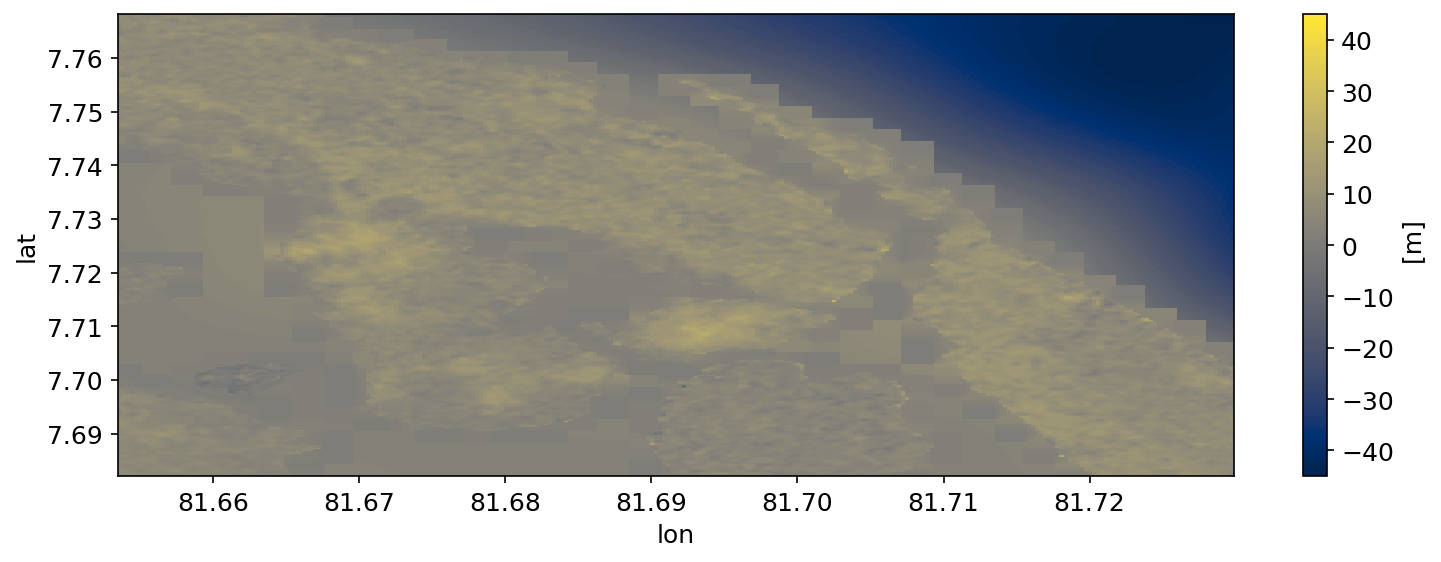

In [ ]:
# download NASA SRTM DEM 1 arc-second
Tiles().download_dem_srtm(AOI, filename=DEM).plot.imshow(cmap='cividis')


Tiles Parallel Downloading:   0%|          | 0/1 [00:00<?, ?it/s]

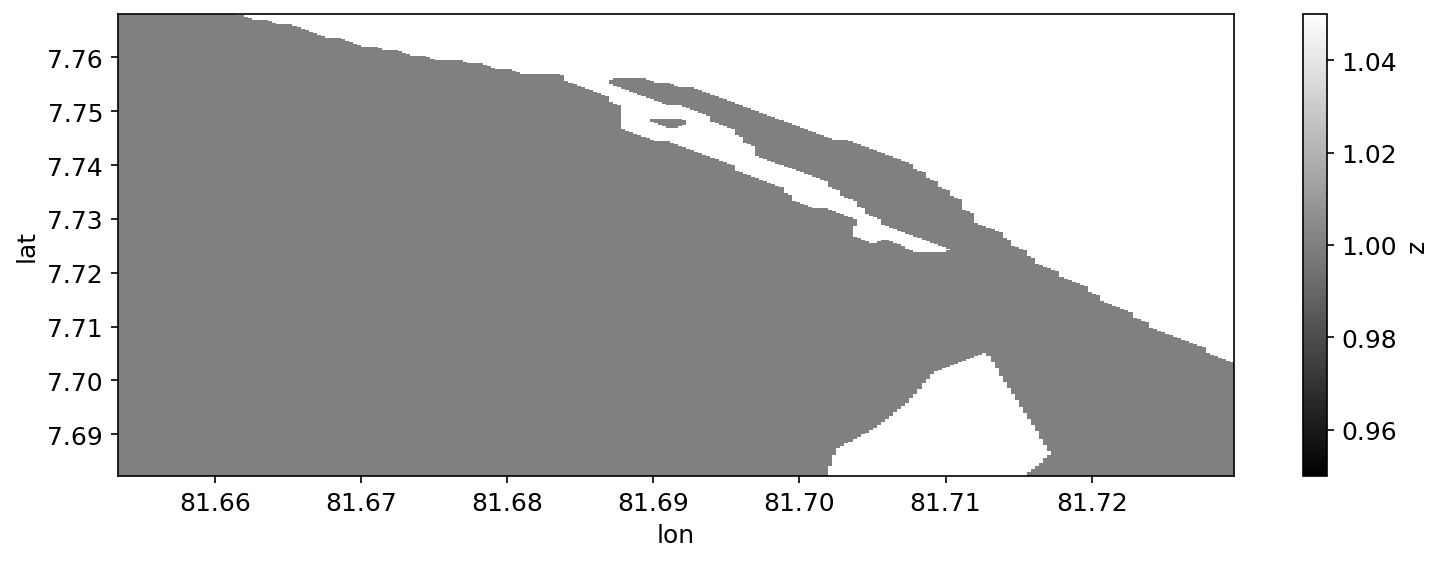

In [ ]:
# download the landmask. Water pixels return noise; without masking they are
# unwrapped and enter the least-squares solution as if they were ground.
Tiles().download_landmask(AOI, filename=LANDMASK).plot.imshow(cmap='binary_r')


## Run Local Dask Cluster

Launch Dask cluster for local and distributed multicore computing. That's possible to process terabyte scale Sentinel-1 SLC datasets on Apple Air 16 GB RAM.

In [ ]:
from dask.distributed import LocalCluster, Client
if 'client' in globals() and hasattr(client, 'close'):
    client.close()
cluster = LocalCluster()
client = Client(cluster.scheduler_address)
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:45267
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:38829'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34109'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:46367'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40659'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:35493 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:35493
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:50302
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:38375 name: 1
INFO:

<Client: 'tcp://127.0.0.1:45267' processes=4 threads=12, memory=52.96 GiB>

## Init

Search recursively for measurement (.tiff) and annotation (.xml) and orbit (.EOF) files in the DATA directory. It can be directory with full unzipped scenes (.SAFE) subdirectories or just a directory with the list of pairs of required .tiff and .xml files (maybe pre-filtered for orbit, polarization and subswath to save disk space). If orbit files and DEM are missed these will be downloaded automatically below.

### Select Original Secenes and Orbits

Use filters to find required subswath, polarization and orbit in original scenes .SAFE directories in the data directory.

In [ ]:
scenes = S1.scan_slc(DATADIR, subswath=SUBSWATH)

In [ ]:
sbas = Stack(WORKDIR, drop_if_exists=True).set_scenes(scenes)

# Search for a scene date in May or June 2023 from the loaded scenes.
new_reference_date_str = None
for date_idx_str in sbas.df.index:
    try:
        # Convert index string to datetime object for month/year comparison
        dt_obj = pd.to_datetime(date_idx_str)
        if dt_obj.year == 2023 and (dt_obj.month == 5 or dt_obj.month == 6):
            new_reference_date_str = date_idx_str
            break # Found a suitable date, exit loop
    except ValueError:
        # Catch cases where the index might not be a valid date string
        # This should ideally not happen if S1.scan_slc works as expected
        continue

if new_reference_date_str:
    sbas.set_reference(new_reference_date_str)
    print(f"Reference scene autoset to: {new_reference_date_str}")
elif REFERENCE in sbas.df.index:
    # Fallback to the globally defined REFERENCE if it's now found (e.g., if date format was the issue)
    sbas.set_reference(REFERENCE)
    print(f"Using globally defined REFERENCE: {REFERENCE}")
else:
    # If no scene in May or June 2023 is found and global REFERENCE is invalid, inform the user.
    print("Could not find any scene in May or June 2023 in the current dataset for reference.")
    print("PyGMTSAR will proceed, likely auto-selecting a reference scene (e.g., the first one in the stack).")
    # No explicit `set_reference` call here to allow PyGMTSAR's default behavior.

sbas.to_dataframe()

NOTE: auto set reference scene 2020-12-22. You can change it like Stack.set_reference("2022-01-20")
Reference scene autoset to: 2023-05-29


,datetime,orbit,mission,polarization,subswath,datapath,metapath,noisepath,calibpath,orbitpath,geometry
date,,,,,,,,,,,
2020-12-22,2020-12-22 00:25:18,D,S1A,VV,1,data_batticaloa_desc/S1A_IW_SLC__1SDV_20201222T002518_20201222T002521_035791_043084_461A.SAFE/me...,data_batticaloa_desc/S1A_IW_SLC__1SDV_20201222T002518_20201222T002521_035791_043084_461A.SAFE/an...,None,None,data_batticaloa_desc/S1A_OPER_AUX_POEORB_OPOD_20210318T232351_V20201221T225942_20201223T005942.EOF,"MULTIPOLYGON (((81.71835 7.7984, 81.67716 7.80686, 81.63636 7.81523, 81.59592 7.82352, 81.55513 ..."
2021-01-27,2021-01-27 00:25:17,D,S1A,VV,1,data_batticaloa_desc/S1A_IW_SLC__1SDV_20210127T002517_20210127T002520_036316_0442D3_46F6.SAFE/me...,data_batticaloa_desc/S1A_IW_SLC__1SDV_20210127T002517_20210127T002520_036316_0442D3_46F6.SAFE/an...,None,None,data_batticaloa_desc/S1A_OPER_AUX_POEORB_OPOD_20210216T121817_V20210126T225942_20210128T005942.EOF,"MULTIPOLYGON (((81.71814 7.79841, 81.67696 7.80687, 81.63615 7.81524, 81.59571 7.82353, 81.55492..."
2021-02-20,2021-02-20 00:25:16,D,S1A,VV,1,data_batticaloa_desc/S1A_IW_SLC__1SDV_20210220T002516_20210220T002519_036666_044EFD_F98C.SAFE/me...,data_batticaloa_desc/S1A_IW_SLC__1SDV_20210220T002516_20210220T002519_036666_044EFD_F98C.SAFE/an...,None,None,data_batticaloa_desc/S1A_OPER_AUX_POEORB_OPOD_20210312T122338_V20210219T225942_20210221T005942.EOF,"MULTIPOLYGON (((81.71873 7.79854, 81.67755 7.80699, 81.63674 7.81537, 81.59631 7.82366, 81.55552..."
2021-03-28,2021-03-28 00:25:16,D,S1A,VV,1,data_batticaloa_desc/S1A_IW_SLC__1SDV_20210328T002516_20210328T002519_037191_046138_A673.SAFE/me...,data_batticaloa_desc/S1A_IW_SLC__1SDV_20210328T002516_20210328T002519_037191_046138_A673.SAFE/an...,None,None,data_batticaloa_desc/S1A_OPER_AUX_POEORB_OPOD_20210417T121642_V20210327T225942_20210329T005942.EOF,"MULTIPOLYGON (((81.71754 7.7989, 81.67636 7.80735, 81.63556 7.81572, 81.59513 7.82402, 81.55435 ..."
2021-04-21,2021-04-21 00:25:17,D,S1A,VV,1,data_batticaloa_desc/S1A_IW_SLC__1SDV_20210421T002517_20210421T002520_037541_046D53_845C.SAFE/me...,data_batticaloa_desc/S1A_IW_SLC__1SDV_20210421T002517_20210421T002520_037541_046D53_845C.SAFE/an...,None,None,data_batticaloa_desc/S1A_OPER_AUX_POEORB_OPOD_20210511T121634_V20210420T225942_20210422T005942.EOF,"MULTIPOLYGON (((81.71856 7.79886, 81.67738 7.80732, 81.63658 7.81569, 81.59614 7.82399, 81.55535..."
2021-05-27,2021-05-27 00:25:19,D,S1A,VV,1,data_batticaloa_desc/S1A_IW_SLC__1SDV_20210527T002519_20210527T002522_038066_047E1E_648C.SAFE/me...,data_batticaloa_desc/S1A_IW_SLC__1SDV_20210527T002519_20210527T002522_038066_047E1E_648C.SAFE/an...,None,None,data_batticaloa_desc/S1A_OPER_AUX_POEORB_OPOD_20210616T121742_V20210526T225942_20210528T005942.EOF,"MULTIPOLYGON (((81.71828 7.79874, 81.6771 7.80719, 81.63629 7.81557, 81.59585 7.82386, 81.55506 ..."
2021-06-20,2021-06-20 00:25:20,D,S1A,VV,1,data_batticaloa_desc/S1A_IW_SLC__1SDV_20210620T002520_20210620T002523_038416_048885_502A.SAFE/me...,data_batticaloa_desc/S1A_IW_SLC__1SDV_20210620T002520_20210620T002523_038416_048885_502A.SAFE/an...,None,None,data_batticaloa_desc/S1A_OPER_AUX_POEORB_OPOD_20210710T121920_V20210619T225942_20210621T005942.EOF,"MULTIPOLYGON (((81.7179 7.79893, 81.67672 7.80739, 81.63591 7.81576, 81.59548 7.82405, 81.5547 7..."
2021-07-26,2021-07-26 00:25:22,D,S1A,VV,1,data_batticaloa_desc/S1A_IW_SLC__1SDV_20210726T002522_20210726T002525_038941_04984C_D353.SAFE/me...,data_batticaloa_desc/S1A_IW_SLC__1SDV_20210726T002522_20210726T002525_038941_04984C_D353.SAFE/an...,None,None,data_batticaloa_desc/S1A_OPER_AUX_POEORB_OPOD_20210815T121820_V20210725T225942_20210727T005942.EOF,"MULTIPOLYGON (((81.71958 7.79828, 81.67839 7.80674, 81.63758 7.81511, 81.59714 7.82341, 81.55635..."
2021-08-31,2021-08-31 00:25:24,D,S1A,VV,1,data_batticaloa_desc/S1A_IW_SLC__1SDV_20210831T002524_20210831T002527_039466_04A9B9_2486.SAFE/me...,data_batticaloa_desc/S1A_IW_SLC__1SDV_20210831T002524_20210831T002527_039466_04A9B9_2486.SAFE/an...,None,None,data_

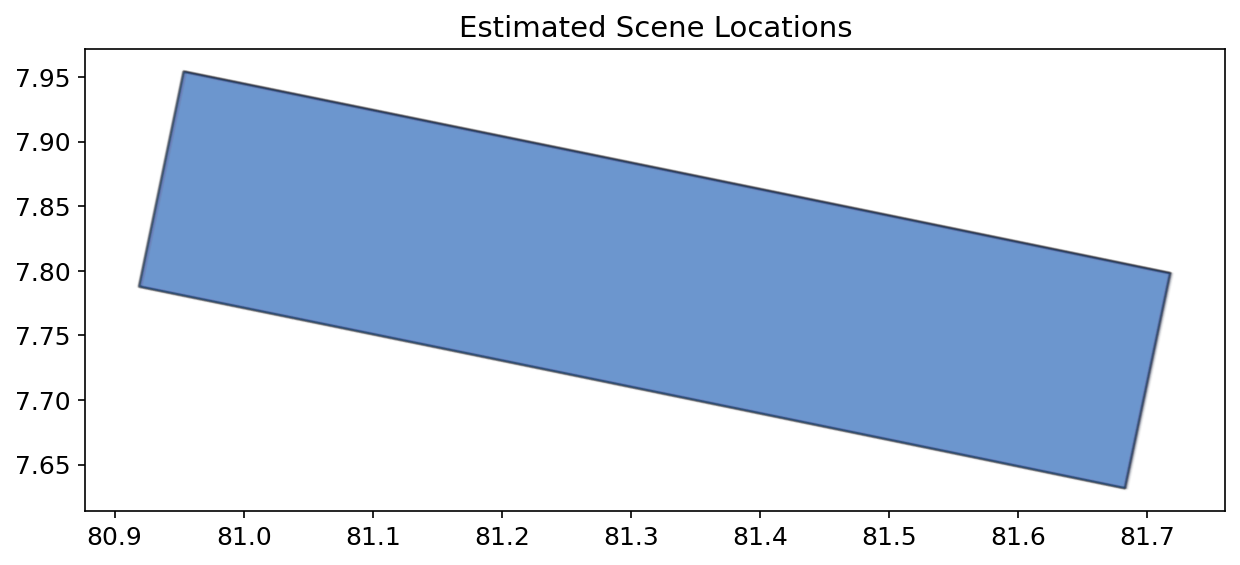

In [ ]:
import matplotlib.pyplot as plt
from pygmtsar import Stack

# Save original method
_original_plot_AOI = Stack.plot_AOI

# Define patched method with the correct signature matching Stack.plot_AOI
# and handling potential empty geometry
def _patched_plot_AOI(self, geometry=None, ax=None, boundary_color='black', **kwargs):
    # If geometry is None or an empty GeoDataFrame, skip plotting to prevent ValueError
    if geometry is None or geometry.empty:
        # Optionally, log a message or just do nothing if there's no valid geometry to plot
        return

    ax = ax or plt.gca()

    # Plot filled area of interest
    geometry.plot(ax=ax, color='grey', **kwargs)

    # Plot boundary of area of interest
    boundaries = geometry.boundary

    # Only plot non-empty boundaries to avoid issues with empty boundary geometries
    # Filtering the GeoSeries returned by .boundary
    non_empty_boundaries = boundaries[~boundaries.is_empty]
    if not non_empty_boundaries.empty:
        non_empty_boundaries.plot(ax=ax, color=boundary_color)

try:
    # Apply the patch temporarily
    Stack.plot_AOI = _patched_plot_AOI
    # Now call the plot_scenes method which will use the patched plot_AOI
    sbas.plot_scenes(AOI=AOI)
finally:
    # Restore the original method to avoid side effects in subsequent calls
    Stack.plot_AOI = _original_plot_AOI

## Reframe Scenes (Optional)

Stitch sequential scenes and crop the subswath to a smaller area for faster processing when the full area is not needed.

In [ ]:
sbas.compute_reframe(AOI)

Reframing: 01...16 from 62:   0%|          | 0/16 [00:00<?, ?it/s]

Reframing: 17...32 from 62:   0%|          | 0/16 [00:00<?, ?it/s]

Reframing: 33...48 from 62:   0%|          | 0/16 [00:00<?, ?it/s]

Reframing: 49...62 from 62:   0%|          | 0/14 [00:00<?, ?it/s]

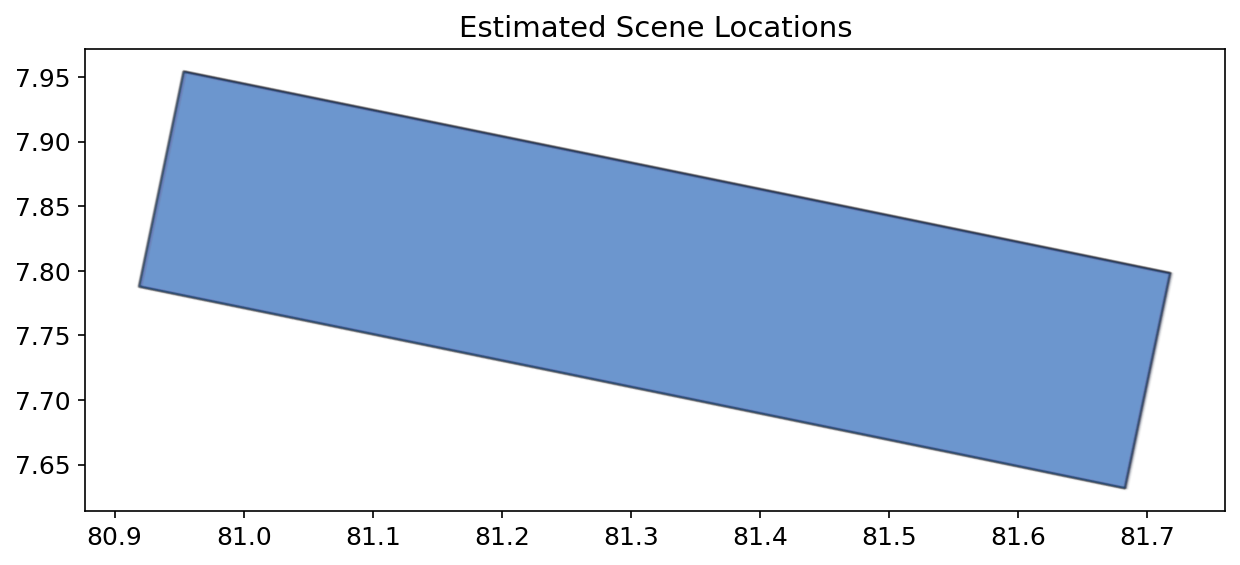

In [ ]:
import matplotlib.pyplot as plt
from pygmtsar import Stack

# Save original method to restore later
_original_plot_AOI = Stack.plot_AOI

# Define patched method with the correct signature matching Stack.plot_AOI
# and handling potential empty geometry
def _patched_plot_AOI(self, geometry=None, ax=None, boundary_color='black', **kwargs):
    # If geometry is None or an empty GeoDataFrame, skip plotting to prevent ValueError
    if geometry is None or geometry.empty:
        # Optionally, log a message or just do nothing if there's no valid geometry to plot
        return

    ax = ax or plt.gca()

    # Plot filled area of interest
    geometry.plot(ax=ax, color='grey', **kwargs)

    # Plot boundary of area of interest
    boundaries = geometry.boundary

    # Only plot non-empty boundaries to avoid issues with empty boundary geometries
    # Filtering the GeoSeries returned by .boundary
    non_empty_boundaries = boundaries[~boundaries.is_empty]
    if not non_empty_boundaries.empty:
        non_empty_boundaries.plot(ax=ax, color=boundary_color)

try:
    # Apply the patch temporarily
    Stack.plot_AOI = _patched_plot_AOI
    # Now call the plot_scenes method which will use the patched plot_AOI
    sbas.plot_scenes(AOI=AOI)
finally:
    # Restore the original method to avoid side effects in subsequent calls
    Stack.plot_AOI = _original_plot_AOI

### Load DEM

The function below loads DEM from file or Xarray variable and converts heights to ellipsoidal model using EGM96 grid.

In [ ]:
# define the area of interest (AOI) to speedup the processing
sbas.load_dem(DEM, AOI)
sbas.load_landmask(LANDMASK)


Save DEM on WGS84 Ellipsoid:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

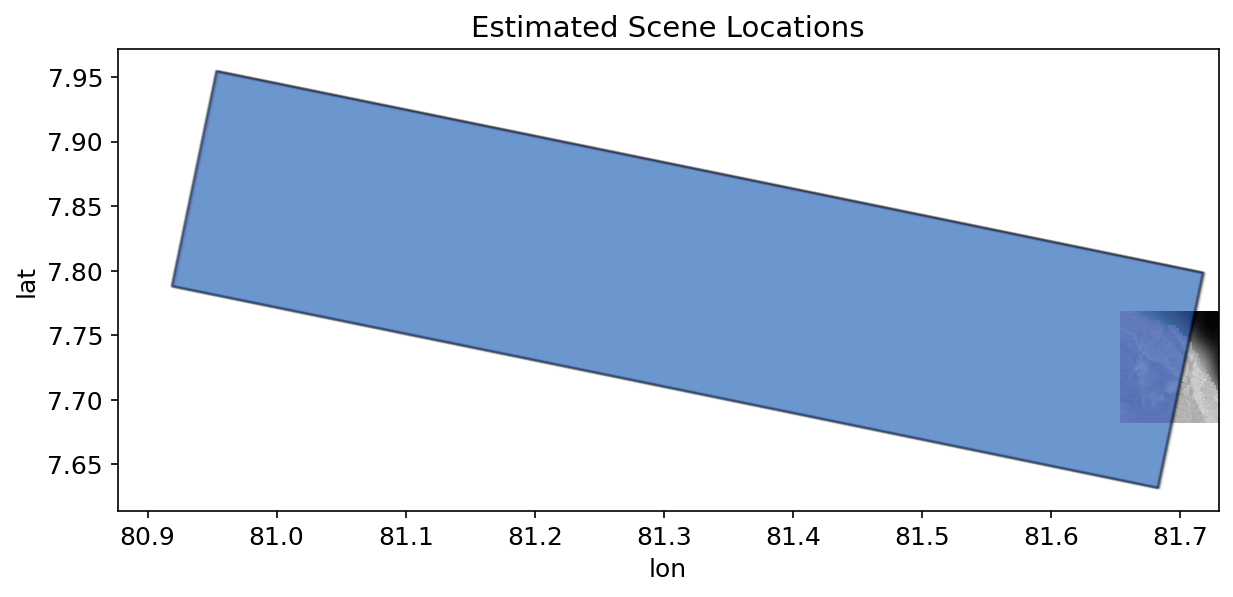

In [ ]:
import matplotlib.pyplot as plt
from pygmtsar import Stack

# Save original method to restore later
_original_plot_AOI = Stack.plot_AOI

# Define patched method with the correct signature matching Stack.plot_AOI
# and handling potential empty geometry
def _patched_plot_AOI(self, geometry=None, ax=None, boundary_color='black', **kwargs):
    # If geometry is None or an empty GeoDataFrame, skip plotting to prevent ValueError
    if geometry is None or geometry.empty:
        # Optionally, log a message or just do nothing if there's no valid geometry to plot
        return

    ax = ax or plt.gca()

    # Plot filled area of interest
    geometry.plot(ax=ax, color='grey', **kwargs)

    # Plot boundary of area of interest
    boundaries = geometry.boundary

    # Only plot non-empty boundaries to avoid issues with empty boundary geometries
    # Filtering the GeoSeries returned by .boundary
    non_empty_boundaries = boundaries[~boundaries.is_empty]
    if not non_empty_boundaries.empty:
        non_empty_boundaries.plot(ax=ax, color=boundary_color)

try:
    # Apply the patch temporarily
    Stack.plot_AOI = _patched_plot_AOI
    # Now call the plot_scenes method which will use the patched plot_AOI
    sbas.plot_scenes(AOI=AOI)
finally:
    # Restore the original method to avoid side effects in subsequent calls
    Stack.plot_AOI = _original_plot_AOI

## Align Images

In [ ]:
sbas.compute_align()

Preparing Reference:   0%|          | 0/1 [00:00<?, ?it/s]

Aligning Repeat:   0%|          | 0/61 [00:00<?, ?it/s]

## Geocoding Transform

In [ ]:
# use the original Sentinel-1 resolution (1 pixel spacing)
sbas.compute_geocode(1)

Radar Transform Computing:   0%|          | 0/1 [00:00<?, ?it/s]

Radar Transform Indexing:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

INFO:distributed.scheduler:Receive client connection: Client-worker-6c8deacb-ac15-11f1-8d9c-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:48256
INFO:distributed.scheduler:Receive client connection: Client-worker-6c9cdee8-ac15-11f1-8da0-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:48268
INFO:distributed.scheduler:Receive client connection: Client-worker-6ca39de0-ac15-11f1-8d97-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:48270
INFO:distributed.scheduler:Receive client connection: Client-worker-6ca7c9cb-ac15-11f1-8da1-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:48282


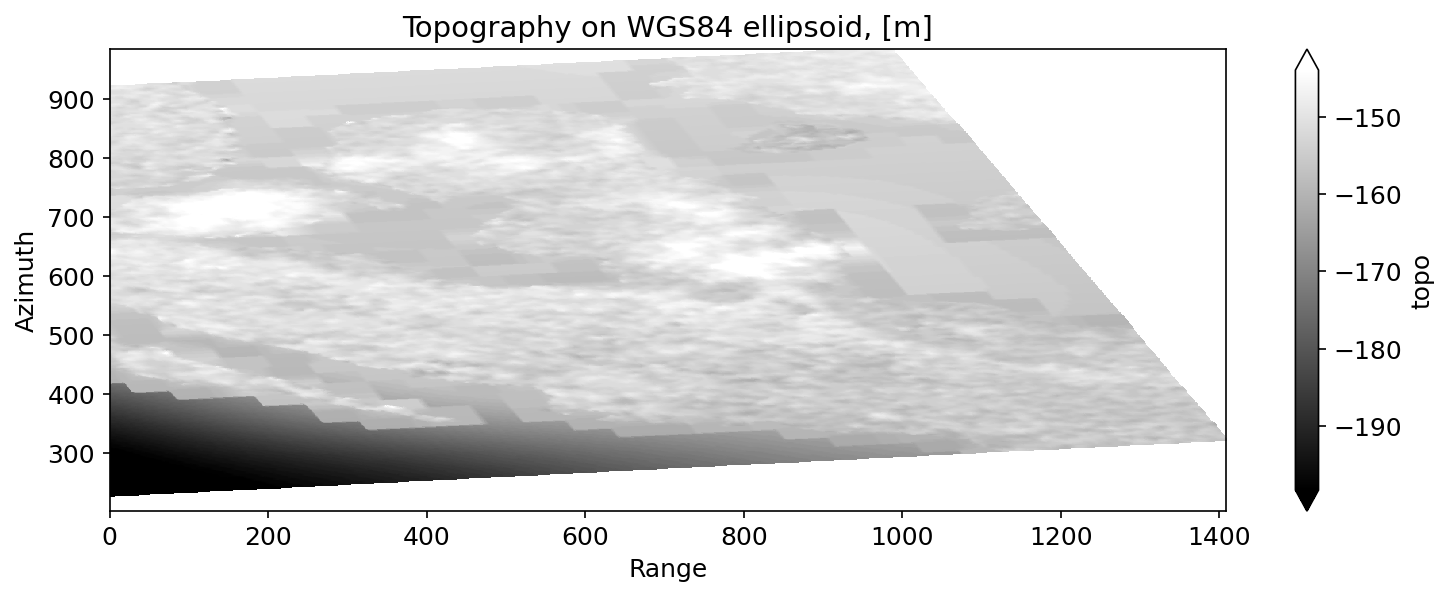

In [ ]:
sbas.plot_topo(quantile=[0.01, 0.99])

## SBAS Baseline

In [ ]:
# 365-day pairs decorrelate almost completely over tropical vegetated coast,
# which is why the original interferograms showed no consistent signal. Short
# temporal baselines plus a perpendicular baseline cap keeps both temporal and
# geometric decorrelation bounded.
baseline_pairs = sbas.sbas_pairs(days=100, meters=150)

# If the stack is still sparse this will return very few pairs - another
# symptom of the sampling problem rather than a reason to widen the window.
print(f'{len(baseline_pairs)} pairs from {len(sbas.to_dataframe())} scenes')
baseline_pairs

150 pairs from 62 scenes


,ref,rep,ref_baseline,rep_baseline,pair,baseline,duration,rel
0,2020-12-22,2021-01-27,-85.62,-62.31,2020-12-22 2021-01-27,23.31,36,NaT
1,2020-12-22,2021-02-20,-85.62,-149.73,2020-12-22 2021-02-20,-64.11,60,NaT
2,2020-12-22,2021-03-28,-85.62,-80.94,2020-12-22 2021-03-28,4.68,96,NaT
3,2021-01-27,2021-02-20,-62.31,-149.73,2021-01-27 2021-02-20,-87.42,24,NaT
4,2021-01-27,2021-03-28,-62.31,-80.94,2021-01-27 2021-03-28,-18.63,60,NaT
5,2021-01-27,2021-04-21,-62.31,-121.73,2021-01-27 2021-04-21,-59.42,84,NaT
6,2021-02-20,2021-03-28,-149.73,-80.94,2021-02-20 2021-03-28,68.79,36,NaT
7,2021-02-20,2021-04-21,-149.73,-121.73,2021-02-20 2021-04-21,28.00,60,NaT
8,2021-02-20,2021-05-27,-149.73,-67.91,2021-02-20 2021-05-27,81.82,96,NaT
9,2021-03-28,2021-04-21,-80.94,-121.73,2021-03-28 2021-04-21,-40.79,24,NaT


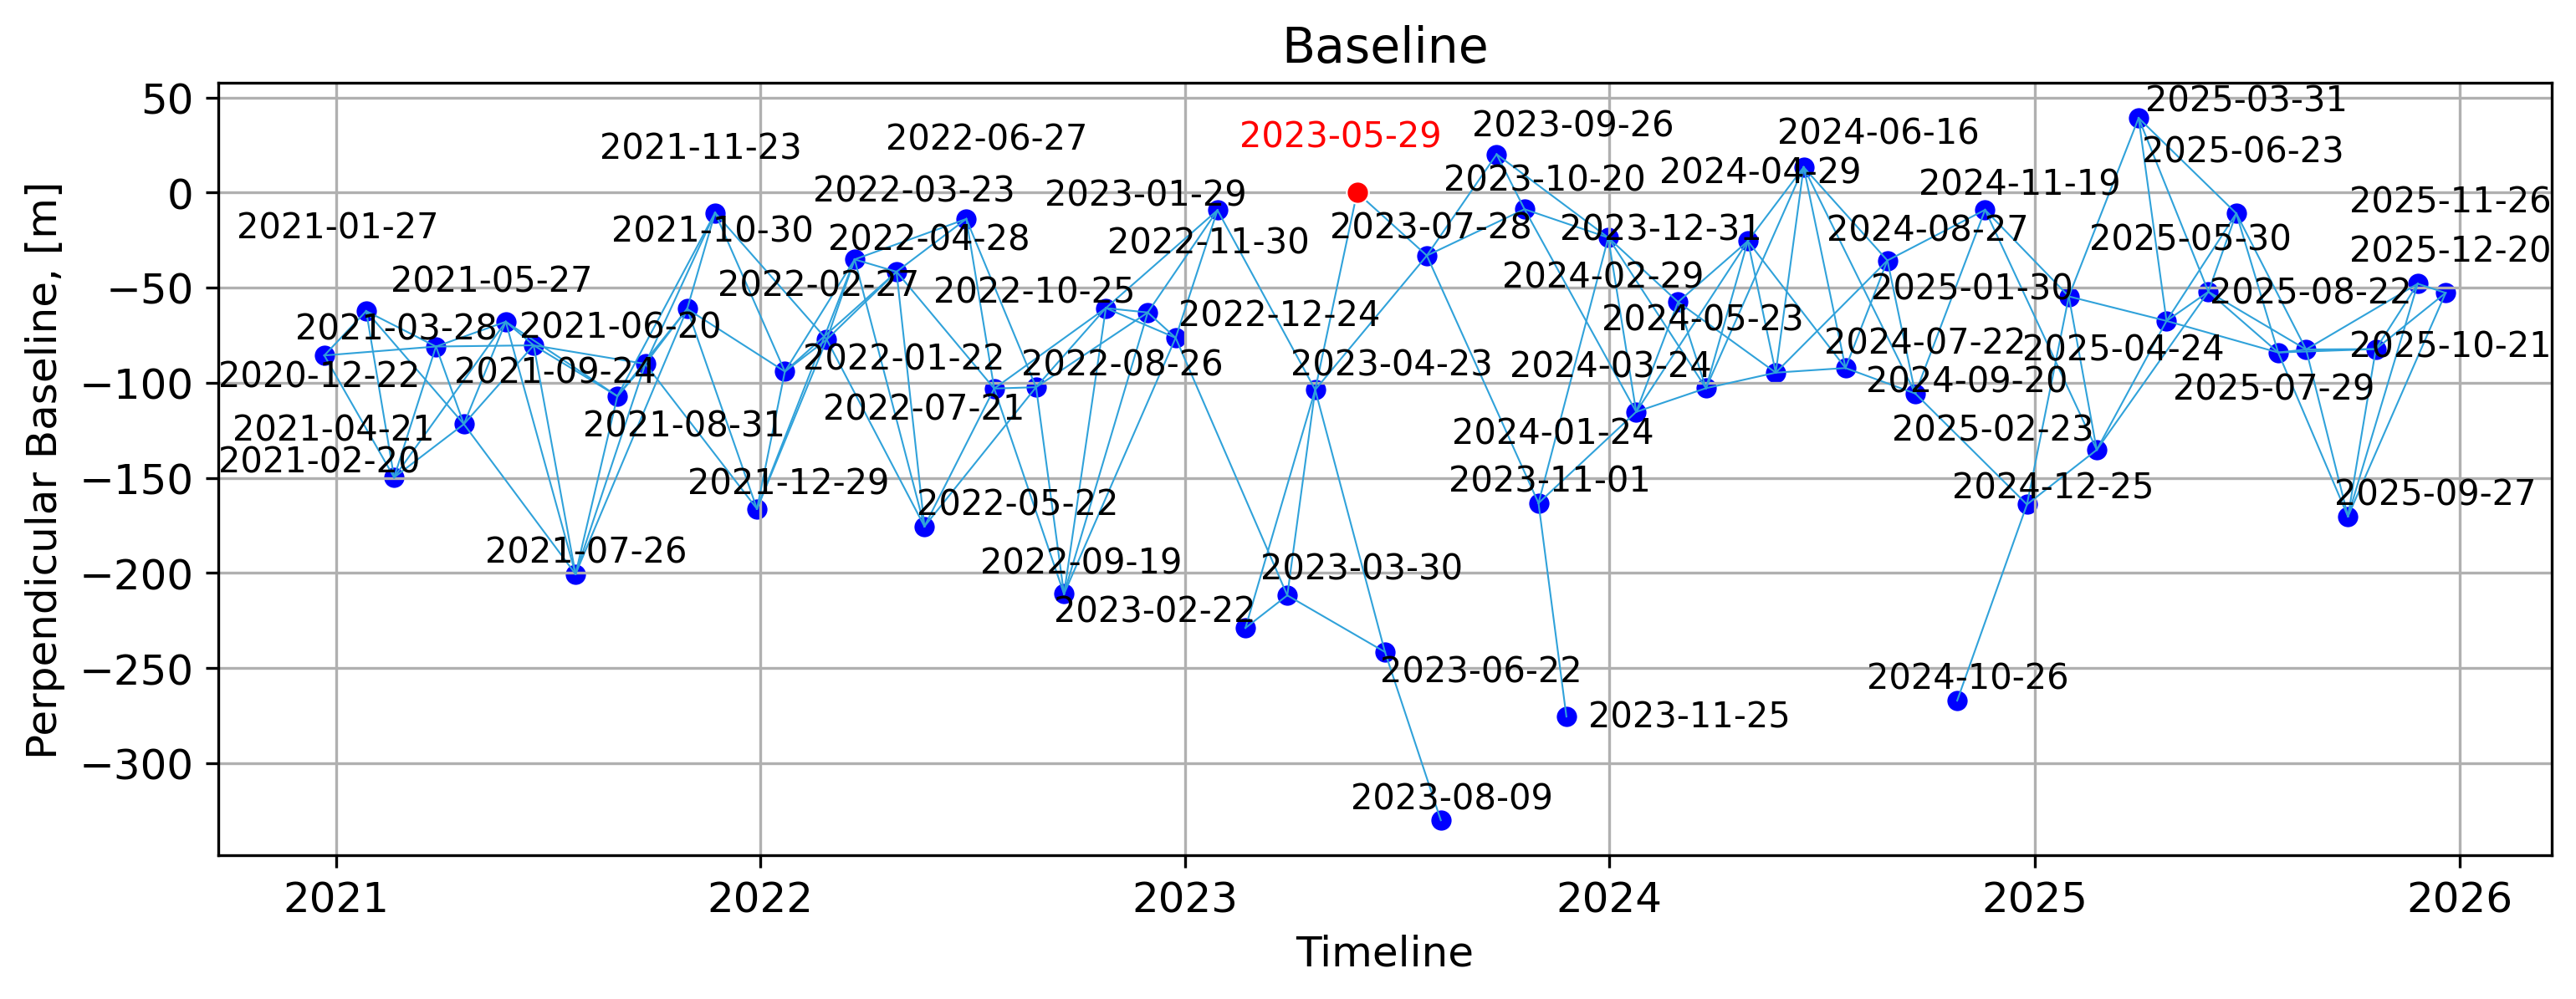

In [ ]:
with mpl_settings({'figure.dpi': 300}):
    sbas.plot_baseline(baseline_pairs)

## Persistent Scatterers Function (PSF)

In [ ]:
# use the only selected dates for the pixels stability analysis
sbas.compute_ps()

Intensity Normalization:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

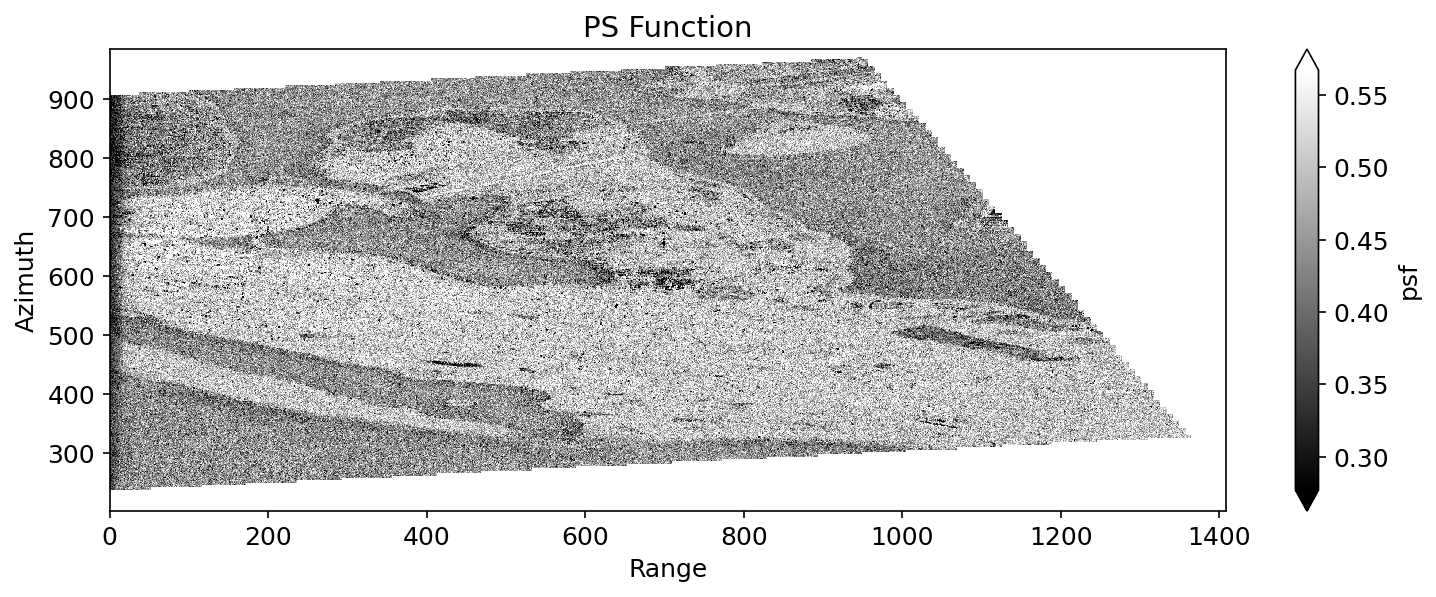

In [ ]:
sbas.plot_psfunction(quantile=[0.01, 0.90])

## SBAS Analysis

### Multi-looked Resolution for SBAS

In [ ]:
sbas.compute_interferogram_multilook(baseline_pairs, 'intf_mlook', wavelength=30, weight=sbas.psfunction())

Debugging information
---------------------
old task state: released
old run_spec: Alias(('concatenate-973568792b56012c1d2a84a0e774177e', 0)->('array-concatenate-973568792b56012c1d2a84a0e774177e', 0))
new run_spec: Alias(('concatenate-973568792b56012c1d2a84a0e774177e', 0)->('array-c8394b8ae91f74132fa100ce06595ae5', 0))
old dependencies: {('array-concatenate-973568792b56012c1d2a84a0e774177e', 0)}
new dependencies: frozenset({('array-c8394b8ae91f74132fa100ce06595ae5', 0)})

Debugging information
---------------------
old task state: released
old run_spec: Alias(('concatenate-2be0b0feda292416a1e00dc81b7472ba', 0)->('array-concatenate-2be0b0feda292416a1e00dc81b7472ba', 0))
new run_spec: Alias(('concatenate-2be0b0feda292416a1e00dc81b7472ba', 0)->('array-886768324c2307df769529cba2a9a0ce', 0))
old dependencies: {('array-concatenate-2be0b0feda292416a1e00dc81b7472ba', 0)}
new dependencies: frozenset({('array-886768324c2307df769529cba2a9a0ce', 0)})

Debugging information
---------------------
ol

In [ ]:
ds_sbas = sbas.open_stack('intf_mlook')
intf_sbas = ds_sbas.phase
corr_sbas = ds_sbas.correlation
corr_sbas

<xarray.DataArray 'correlation' (pair: 150, y: 783, x: 351)> Size: 165MB
dask.array<rechunk-merge, shape=(150, 783, 351), dtype=float32, chunksize=(1, 783, 351), chunktype=numpy.ndarray>
Coordinates:
  * pair     (pair) <U21 13kB '2020-12-22 2021-01-27' ... '2025-11-26 2025-12...
    ref      (pair) datetime64[ns] 1kB dask.array<chunksize=(1,), meta=np.ndarray>
    rep      (pair) datetime64[ns] 1kB dask.array<chunksize=(1,), meta=np.ndarray>
  * y        (y) float64 6kB 202.5 203.5 204.5 205.5 ... 981.5 982.5 983.5 984.5
  * x        (x) float64 3kB 4.0 8.0 12.0 16.0 ... 1.396e+03 1.4e+03 1.404e+03

In [ ]:
intf_sbas

<xarray.DataArray 'phase' (pair: 150, y: 783, x: 351)> Size: 165MB
dask.array<rechunk-merge, shape=(150, 783, 351), dtype=float32, chunksize=(1, 783, 351), chunktype=numpy.ndarray>
Coordinates:
  * pair     (pair) <U21 13kB '2020-12-22 2021-01-27' ... '2025-11-26 2025-12...
    ref      (pair) datetime64[ns] 1kB dask.array<chunksize=(1,), meta=np.ndarray>
    rep      (pair) datetime64[ns] 1kB dask.array<chunksize=(1,), meta=np.ndarray>
  * y        (y) float64 6kB 202.5 203.5 204.5 205.5 ... 981.5 982.5 983.5 984.5
  * x        (x) float64 3kB 4.0 8.0 12.0 16.0 ... 1.396e+03 1.4e+03 1.404e+03

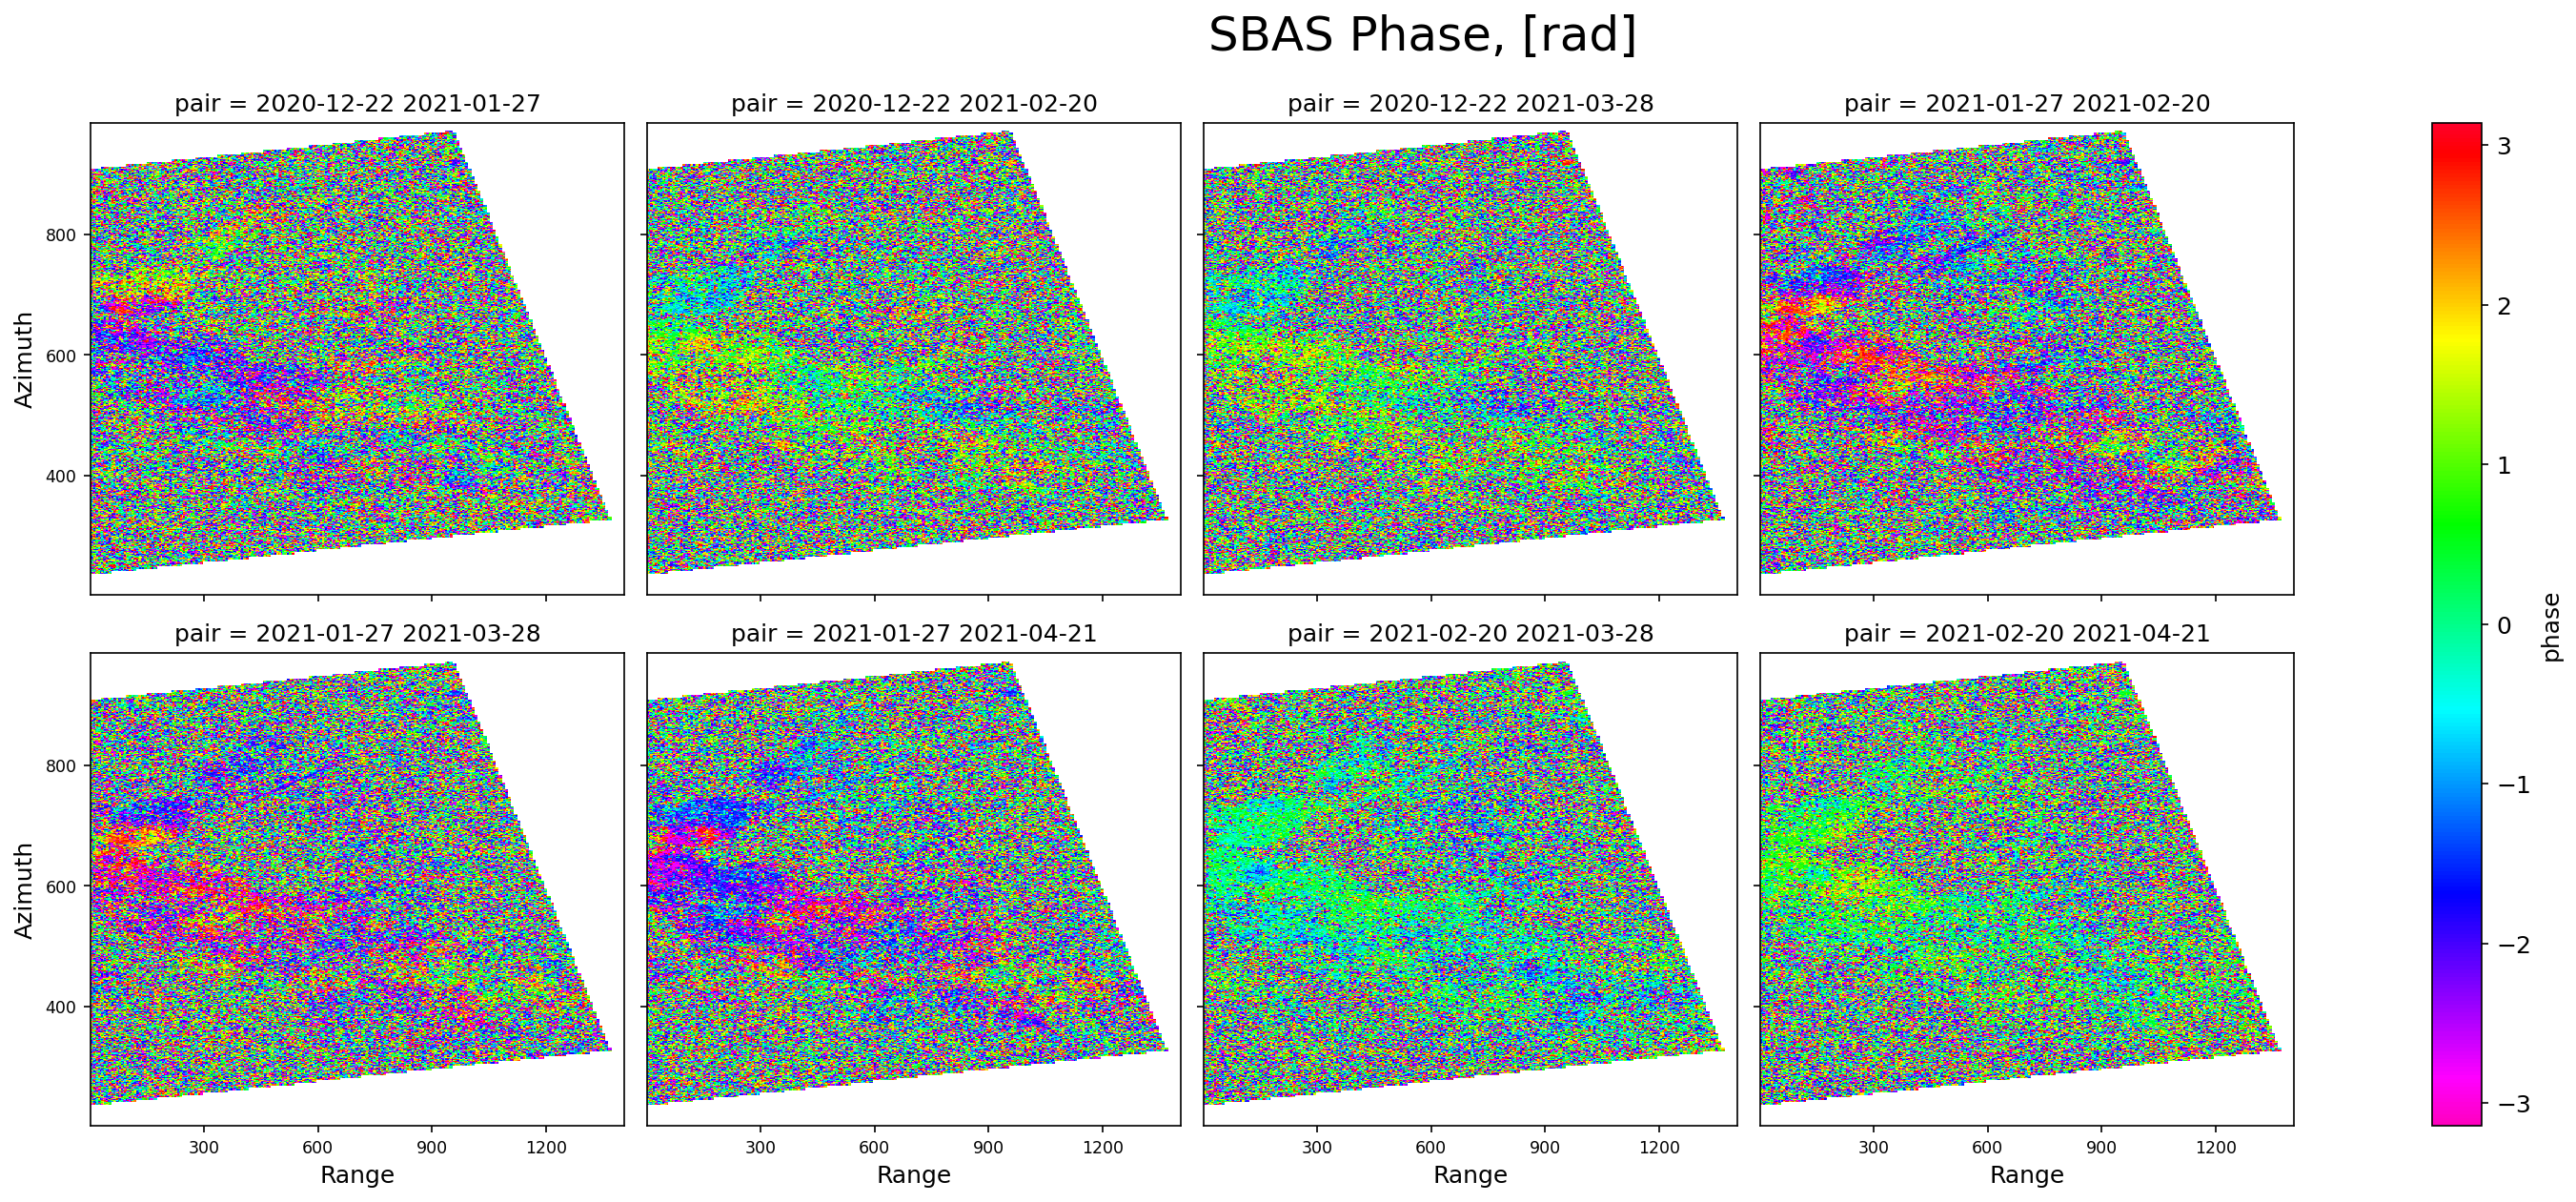

In [ ]:
sbas.plot_interferograms(intf_sbas[:8], caption='SBAS Phase, [rad]')

In [ ]:
sbas.plot_correlations(corr_sbas[:8], caption='SBAS Correlation')

### 2D Unwrapping

In [ ]:
unwrap_sbas = sbas.unwrap_snaphu(intf_sbas, corr_sbas)
unwrap_sbas

In [ ]:
# optionally, materialize to disk and open
unwrap_sbas = sbas.sync_cube(unwrap_sbas, 'unwrap_sbas')

In [ ]:
sbas.plot_phases(unwrap_sbas.phase[:8], caption='SBAS Phase, [rad]')

### Trend Correction

In [ ]:
decimator = sbas.decimator(resolution=15, grid=(1,1))
topo = decimator(sbas.get_topo())
inc = decimator(sbas.incidence_angle())
yy, xx = xr.broadcast(topo.y, topo.x)

# Normalise the coordinates so the polynomial terms are conditioned.
yyn = (yy - yy.mean()) / yy.std()
xxn = (xx - xx.mean()) / xx.std()

# The original model had 25 basis functions including cubic terms in x and y.
# Over an AOI a couple of kilometres across, a cubic surface will happily
# absorb a real subsidence bowl into the "trend" and remove it. Reduced here to
# topography plus a quadratic ramp.
#
# The original also contained `inc**yy` - exponentiation, where every
# neighbouring term used multiplication. That is a typo inherited from the
# upstream template: `yy` is large in radar coordinates, so the term either
# overflows or dominates the design matrix. Corrected to `inc*yyn` below.
trend_sbas = sbas.regression(
    unwrap_sbas.phase,
    [topo, topo*yyn, topo*xxn,      # topography-correlated atmospheric delay
     inc,  inc*yyn,  inc*xxn,       # incidence-angle terms (multiplied, not **)
     yyn,  xxn,                     # linear ramp (residual orbital)
     yyn**2, xxn**2, yyn*xxn],      # quadratic ramp
    corr_sbas)


In [ ]:
# optionally, materialize to disk and open
trend_sbas = sbas.sync_cube(trend_sbas, 'trend_sbas')

In [ ]:
# Sanity check on the trend model. If removing the trend flattens the
# subsidence signal, the model is too rich and is eating the deformation.
print('phase std      :', float(unwrap_sbas.phase.std()))
print('trend std      :', float(trend_sbas.std()))
print('residual std   :', float((unwrap_sbas.phase - trend_sbas).std()))
print('variance removed by trend: '
      f'{1 - float((unwrap_sbas.phase - trend_sbas).var() / unwrap_sbas.phase.var()):.1%}')


In [ ]:
sbas.plot_phases(trend_sbas[:8], caption='SBAS Trend Phase, [rad]', quantile=[0.01, 0.99])

In [ ]:
sbas.plot_phases((unwrap_sbas.phase - trend_sbas)[:8], caption='SBAS Phase - Trend, [rad]', vmin=-np.pi, vmax=np.pi)

### Coherence-Weighted Least-Squares Solution for LOS Displacement, mm

In [ ]:
# calculate phase displacement in radians and convert to LOS displacement in millimeter
disp_sbas = sbas.los_displacement_mm(sbas.lstsq(unwrap_sbas.phase - trend_sbas, corr_sbas))

In [ ]:
# optionally, materialize to disk and open
disp_sbas = sbas.sync_cube(disp_sbas, 'disp_sbas')

In [ ]:
sbas.plot_displacements(disp_sbas[::3], caption='SBAS Cumulative LOS Displacement, [mm]', quantile=[0.01, 0.99])

### SBAS RMSE Error Estimation

The original notebook computed RMSE for the PS branch only. Reviewer 1 asked
for evidence of reliability, so both branches need it.


In [ ]:
rmse_sbas = sbas.rmse(
    sbas.los_displacement_mm(unwrap_sbas.phase - trend_sbas),
    disp_sbas, corr_sbas)
rmse_sbas = sbas.sync_cube(rmse_sbas, 'rmse_sbas')
sbas.plot_rmse(rmse_sbas, caption='SBAS RMSE Correlation Aware, [mm]')


### Least-squares model for LOS Displacement, mm

In [ ]:
def velocity_with_stderr(disp):
    """Per-pixel OLS velocity and its standard error.

    disp : DataArray with a 'date' dimension, units mm.
    Returns (velocity mm/yr, stderr mm/yr, n_obs).

    A velocity map with no uncertainty cannot demonstrate reliability, which is
    the core of Reviewer 1's first comment.
    """
    t = (disp.date - disp.date[0]).dt.days.astype('float64') / 365.25
    n = disp.notnull().sum('date')

    tbar = t.mean()
    ybar = disp.mean('date')
    sxx = ((t - tbar) ** 2).sum()
    sxy = ((t - tbar) * (disp - ybar)).sum('date')

    slope = sxy / sxx
    intercept = ybar - slope * tbar
    resid = disp - (slope * t + intercept)
    s2 = (resid ** 2).sum('date') / (n - 2)     # 2 fitted parameters
    stderr = np.sqrt(s2 / sxx)
    return slope, stderr, n


velocity_sbas, velocity_sbas_se, nobs_sbas = velocity_with_stderr(disp_sbas)
velocity_sbas


In [ ]:
# optionally, materialize to disk and open
velocity_sbas = sbas.sync_cube(velocity_sbas, 'velocity_sbas')
velocity_sbas_se = sbas.sync_cube(velocity_sbas_se, 'velocity_sbas_se')

for _label, _pt in [('POI (target)   ', POI), ('POI0 (reference)', POI0)]:
    _x, _y = [(g.x, g.y) for g in sbas.geocode(_pt).geometry][0]
    _v = float(velocity_sbas.sel(y=_y, x=_x, method='nearest'))
    _se = float(velocity_sbas_se.sel(y=_y, x=_x, method='nearest'))
    print(f'{_label}: {_v:+7.2f} +/- {1.96*_se:5.2f} mm/yr (95% CI)')


In [ ]:
def plot_velocity(velocity, stderr, method, fname=None):
    """Publication velocity figure.

    Changes from the original: fixed colour scale shared across all four
    lagoons (the original recomputed quantiles per figure, so panels were not
    comparable), diverging colormap instead of 'turbo', larger single panel
    instead of two cramped subplots, readable fonts at print size, hatching
    where velocity is not significantly different from zero, and the analysis
    window in the title instead of the hardcoded '2021' left over from the
    template.
    """
    fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

    v_ll = sbas.as_geo(sbas.ra2ll(velocity)).rio.clip(AOI.geometry.buffer(-BUFFER))
    se_ll = sbas.as_geo(sbas.ra2ll(stderr)).rio.clip(AOI.geometry.buffer(-BUFFER))

    im = v_ll.plot.imshow(cmap=CMAP, vmin=VEL_VMIN, vmax=VEL_VMAX,
                          ax=ax, add_colorbar=False)

    # hatch pixels whose velocity is not distinguishable from zero at 95%
    ax.contourf(v_ll[v_ll.rio.x_dim], v_ll[v_ll.rio.y_dim], (abs(v_ll) < 1.96 * se_ll).astype(float),
                levels=[0.5, 1.5], colors='none', hatches=['xxx'])

    AOI.buffer(-BUFFER).boundary.plot(ax=ax, color='k', lw=1)
    POI.plot(ax=ax, marker='^', c='k', markersize=90, label='Target', zorder=5)
    POI0.plot(ax=ax, marker='s', c='k', markersize=90, label='Reference', zorder=5)

    cbar = fig.colorbar(im, ax=ax, shrink=0.8, extend='both')
    cbar.set_label('LOS velocity (mm yr$^{-1}$)', fontsize=13)
    cbar.ax.tick_params(labelsize=12)

    ax.set_xlabel('Longitude ($^\circ$E)', fontsize=13)
    ax.set_ylabel('Latitude ($^\circ$N)', fontsize=13)
    ax.tick_params(labelsize=12)
    ax.legend(loc='upper left', fontsize=12, framealpha=0.9)
    ax.set_title(f'{method} LOS velocity, {SITE.title()} ({ORBIT})\n'
                 f'{ANALYSIS_START[:7]} to {ANALYSIS_END[:7]}  '
                 f'(hatched: not significant at 95%)', fontsize=13)

    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=300, bbox_inches='tight')
        plt.savefig(fname.replace('.png', '.pdf'), bbox_inches='tight')  # vector
    plt.show()


plot_velocity(velocity_sbas, velocity_sbas_se, 'SBAS',
              f'fig_{SITE}_{ORBIT}_sbas_velocity.png')

### STL model for LOS Displacement, mm

In [ ]:
from statsmodels.tsa.seasonal import STL


def stl_sensitivity(disp, poi, label, seasonal_spans=(7, 9, 13, 21, 35),
                    trend_spans=(None, 25, 37, 49)):
    """Tabulate how the STL trend estimate moves with the smoothing windows.

    This is Reviewer 2's comment 3. On a two-per-year stack the spread will be
    large, which is itself the finding: the decomposition is not identifiable
    at that sampling and no single STL rate should be reported.
    """
    x, y = [(g.x, g.y) for g in sbas.geocode(poi).geometry][0]
    ts = disp.sel(y=y, x=x, method='nearest').to_series().dropna()

    # STL needs regular spacing
    ts_m = ts.resample('MS').mean()
    n_missing = int(ts_m.isna().sum())
    ts_m = ts_m.interpolate('linear').dropna()

    rows = []
    for ss in seasonal_spans:
        for tsp in trend_spans:
            try:
                res = STL(ts_m, period=12, seasonal=ss, trend=tsp,
                          robust=True).fit()
            except ValueError:
                continue
            years = (res.trend.index[-1] - res.trend.index[0]).days / 365.25
            rows.append(dict(
                seasonal=ss, trend=tsp if tsp else 'auto',
                trend_rate=(res.trend.iloc[-1] - res.trend.iloc[0]) / years,
                seasonal_amp=res.seasonal.max() - res.seasonal.min(),
                resid_std=res.resid.std(),
                var_explained=1 - res.resid.var() / ts_m.var()))

    df = pd.DataFrame(rows)
    spread = df.trend_rate.max() - df.trend_rate.min()
    print(f'--- {label} ---')
    print(f'{n_missing} of {len(ts_m)} monthly points interpolated '
          f'({n_missing/len(ts_m):.0%})')
    print(f'trend rate {df.trend_rate.mean():+.2f} +/- {df.trend_rate.std():.2f}'
          f' mm/yr, spread {spread:.2f} mm/yr across parameters')
    if n_missing / len(ts_m) > 0.5:
        print('WARN  Over half the series is interpolated. The seasonal '
              'component is an artefact\n      of interpolation, not a '
              'measurement.')
    if spread > 0.3 * abs(df.trend_rate.mean()):
        print('WARN  Trend is not robust to the smoothing windows. Do not '
              'report a single STL\n      rate without this uncertainty.')
    print()
    return df


def plot_stl(disp, method, fname=None):
    """Trend / seasonal / residual panels.

    Reviewer 1 noted that STL is described in the methods but never shown.
    These are the panels that need to appear in the manuscript.
    """
    fig, axes = plt.subplots(3, 1, figsize=(9, 8), dpi=300, sharex=True)

    for pt, c, lab in [(POI, 'tab:red', 'Target'),
                       (POI0, 'tab:blue', 'Reference')]:
        x, y = [(g.x, g.y) for g in sbas.geocode(pt).geometry][0]
        obs = disp.sel(y=y, x=x, method='nearest')
        stl = sbas.stl(disp.sel(y=[y], x=[x], method='nearest')).isel(x=0, y=0)

        axes[0].plot(obs.date, obs, c=c, lw=0.9, alpha=0.5)
        axes[0].plot(stl.date, stl.trend, c=c, lw=2, label=lab)
        axes[1].plot(stl.date, stl.seasonal, c=c, lw=1.2, label=lab)
        resampled_obs = obs.interp(date=stl.date, kwargs={"fill_value": "extrapolate"})
        axes[2].plot(stl.date, resampled_obs - stl.trend - stl.seasonal, c=c, lw=0.8,
                     alpha=0.7, label=lab)

    for ax, t in zip(axes, ['Observed and trend', 'Seasonal', 'Residual']):
        ax.set_ylabel('Displacement (mm)', fontsize=12)
        ax.set_title(t, fontsize=12, loc='left')
        ax.tick_params(labelsize=11)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=11, ncol=2)
    axes[2].set_xlabel('Date', fontsize=12)

    fig.suptitle(f'{method} LOS displacement, STL decomposition\n'
                 f'{SITE.title()} ({ORBIT}), '
                 f'{ANALYSIS_START[:7]} to {ANALYSIS_END[:7]}', fontsize=13)
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=300, bbox_inches='tight')
        plt.savefig(fname.replace('.png', '.pdf'), bbox_inches='tight')
    plt.show()


plot_stl(disp_sbas, 'SBAS', f'fig_{SITE}_{ORBIT}_sbas_stl.png')

sens_sbas = stl_sensitivity(disp_sbas, POI, 'SBAS, target point')
sens_sbas.to_csv(f'stl_sensitivity_{SITE}_{ORBIT}_sbas.csv', index=False)
print(sens_sbas.to_string(index=False))

## PS Analysis

Use the trend detected on possibly lower resolution unwrapped phases for higher resolution analysis.

In [ ]:
sbas.compute_interferogram_singlelook(baseline_pairs, 'intf_slook', wavelength=30,
                                      weight=sbas.psfunction(), phase=trend_sbas)

In [ ]:
ds_ps = sbas.open_stack('intf_slook')
intf_ps = ds_ps.phase
corr_ps = ds_ps.correlation

In [ ]:
sbas.plot_interferograms(intf_ps[:8], caption='PS Phase, [rad]')

In [ ]:
sbas.plot_correlations(corr_ps[:8], caption='PS Correlation')

### 1D Unwrapping and LOS Displacement, mm

In [ ]:
# .compute() forces materialisation before 1D unwrapping. Without it the
# descending run can exhaust memory on a dense stack.
intf_ps_computed = intf_ps.compute()
disp_ps_pairs = sbas.los_displacement_mm(sbas.unwrap1d(intf_ps_computed))
disp_ps_pairs


In [ ]:
disp_ps_pairs = disp_ps_pairs.compute()
# optionally, materialize to disk and open
disp_ps_pairs = sbas.sync_cube(disp_ps_pairs, 'disp_ps_pairs')


### Coherence-Weighted Least-Squares Solution for LOS Displacement, mm

In [ ]:
disp_ps = sbas.lstsq(disp_ps_pairs, corr_ps)
disp_ps

In [ ]:
# optionally, materialize to disk and open
disp_ps = sbas.sync_cube(disp_ps, 'disp_ps')

In [ ]:
zmin, zmax = np.nanquantile(disp_ps, [0.01, 0.99])
sbas.plot_displacements(disp_ps[::3], caption='PS Cumulative LOS Displacement, [mm]', vmin=zmin, vmax=zmax)

### Least-squares model for LOS Displacement, mm

In [ ]:
velocity_ps, velocity_ps_se, nobs_ps = velocity_with_stderr(disp_ps)
velocity_ps


In [ ]:
# optionally, materialize to disk and open
velocity_ps = sbas.sync_cube(velocity_ps, 'velocity_ps')
velocity_ps_se = sbas.sync_cube(velocity_ps_se, 'velocity_ps_se')


In [ ]:
plot_velocity(velocity_ps, velocity_ps_se, 'PSI',
              f'fig_{SITE}_{ORBIT}_psi_velocity.png')


### STL model for LOS Displacement, mm

In [ ]:
plot_stl(disp_ps, 'PSI', f'fig_{SITE}_{ORBIT}_psi_stl.png')

sens_ps = stl_sensitivity(disp_ps, POI, 'PSI, target point')
sens_ps.to_csv(f'stl_sensitivity_{SITE}_{ORBIT}_psi.csv', index=False)
print(sens_ps.to_string(index=False))


In [ ]:
x, y = [(geom.x, geom.y) for geom in sbas.geocode(POI0).geometry][0]
sbas.plot_baseline_displacement_los_mm(disp_ps_pairs.sel(y=y, x=x, method='nearest')/sbas.los_displacement_mm(1),
                                corr_ps.sel(y=y, x=x, method='nearest'),
                               caption='POI0', stl=True)

In [ ]:
x, y = [(geom.x, geom.y) for geom in sbas.geocode(POI).geometry][0]
sbas.plot_baseline_displacement_los_mm(disp_ps_pairs.sel(y=y, x=x, method='nearest')/sbas.los_displacement_mm(1),
                                corr_ps.sel(y=y, x=x, method='nearest'),
                               caption='POI', stl=True)

### RMSE Error Estimation

In [ ]:
rmse_ps = sbas.rmse(disp_ps_pairs, disp_ps, corr_ps)
rmse_ps

In [ ]:
# optionally, materialize to disk and open
rmse_ps = sbas.sync_cube(rmse_ps, 'rmse_ps')

In [ ]:
sbas.plot_rmse(rmse_ps, caption='RMSE Correlation Aware, [mm]')

## SBAS vs PSI Comparison

This figure is the direct answer to Reviewer 1's last comment. A bare scatter
plot does not answer it: the comparison needs R-squared, RMSE, bias and n on
the figure, and the physical reason for any disagreement in the text.

The expected reason for divergence here is that PSI retains coherent hard
targets while SBAS averages distributed scatterers, so the two sample
different ground. Over built-up Puliyanthivu they should agree; over
vegetation and lagoon margins they should not. The stratified comparison below
tests that.


In [ ]:
from scipy import stats


def compare_sbas_psi(velocity_sbas, velocity_ps, fname=None):
    a = sbas.as_geo(sbas.ra2ll(velocity_sbas)).rio.clip(AOI.geometry.buffer(-BUFFER))
    b = sbas.as_geo(sbas.ra2ll(velocity_ps)).rio.clip(AOI.geometry.buffer(-BUFFER))
    b = b.interp_like(a, method='nearest')

    x = a.values.ravel()
    y = b.values.ravel()
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]

    reg = stats.linregress(x, y)
    rmse = float(np.sqrt(np.mean((y - x) ** 2)))
    bias = float(np.mean(y - x))
    nmad = 1.4826 * float(np.median(np.abs((y - x) - np.median(y - x))))

    fig, ax = plt.subplots(figsize=(6.5, 6), dpi=300)
    hb = ax.hexbin(x, y, gridsize=60, cmap='viridis', mincnt=1, bins='log')
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, 'k--', lw=1.2, label='1:1')
    ax.plot(lims, [reg.intercept + reg.slope * v for v in lims], 'r-', lw=1.2,
            label=f'fit (slope {reg.slope:.2f})')

    ax.text(0.04, 0.96,
            f'$n$ = {len(x):,}\n$R^2$ = {reg.rvalue**2:.3f}\n'
            f'RMSE = {rmse:.2f} mm yr$^{{-1}}$\n'
            f'bias = {bias:+.2f} mm yr$^{{-1}}$\n'
            f'NMAD = {nmad:.2f} mm yr$^{{-1}}$',
            transform=ax.transAxes, va='top', fontsize=11,
            bbox=dict(fc='white', alpha=0.85, ec='0.7'))

    fig.colorbar(hb, ax=ax, shrink=0.8, label='point density (log)')
    ax.set_xlabel('SBAS velocity (mm yr$^{-1}$)', fontsize=13)
    ax.set_ylabel('PSI velocity (mm yr$^{-1}$)', fontsize=13)
    ax.set_title(f'SBAS vs PSI, {SITE.title()} ({ORBIT})', fontsize=14)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_aspect('equal')

    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=300, bbox_inches='tight')
        plt.savefig(fname.replace('.png', '.pdf'), bbox_inches='tight')
    plt.show()

    return dict(n=len(x), r2=reg.rvalue**2, slope=reg.slope,
                intercept=reg.intercept, rmse=rmse, bias=bias, nmad=nmad)


comparison_stats = compare_sbas_psi(
    velocity_sbas, velocity_ps, f'fig_{SITE}_{ORBIT}_sbas_vs_psi.png')
print(comparison_stats)


In [ ]:
# Stratify the comparison by coherence. Agreement should improve with
# coherence; if it does not, the disagreement is not a decorrelation effect and
# needs a different explanation in the manuscript.
_corr = sbas.as_geo(sbas.ra2ll(corr_sbas.mean('pair'))).rio.clip(
    AOI.geometry.buffer(-BUFFER))
_a = sbas.as_geo(sbas.ra2ll(velocity_sbas)).rio.clip(AOI.geometry.buffer(-BUFFER))
_b = sbas.as_geo(sbas.ra2ll(velocity_ps)).rio.clip(
    AOI.geometry.buffer(-BUFFER)).interp_like(_a, method='nearest')
_c = _corr.interp_like(_a, method='nearest')

rows = []
for lo, hi in [(0.0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.0)]:
    m = ((_c >= lo) & (_c < hi)).values.ravel()
    x, y = _a.values.ravel(), _b.values.ravel()
    ok = m & np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 50:
        continue
    rows.append(dict(coherence=f'{lo:.1f}-{hi:.1f}', n=int(ok.sum()),
                     r2=stats.linregress(x[ok], y[ok]).rvalue**2,
                     rmse=float(np.sqrt(np.mean((y[ok] - x[ok])**2))),
                     bias=float(np.mean(y[ok] - x[ok]))))

strat = pd.DataFrame(rows)
strat.to_csv(f'{SITE}_{ORBIT}_sbas_psi_by_coherence.csv', index=False)
print(strat.to_string(index=False))


velocity_sbas_ll = sbas.ra2ll(velocity_sbas)
velocity_ps_ll = sbas.ra2ll(velocity_ps)
# crop to area
velocity_sbas_ll = sbas.as_geo(velocity_sbas_ll).rio.clip(AOI.geometry.buffer(-BUFFER))
velocity_ps_ll = sbas.as_geo(velocity_ps_ll).rio.clip(AOI.geometry.buffer(-BUFFER))
# Explicitly name the DataArrays before exporting to ensure the scalar is named 'velocity' in the VTK files.
velocity_sbas_ll.name = 'velocity'
velocity_ps_ll.name = 'velocity'
# export VTK
sbas.export_vtk(velocity_sbas_ll, 'velocity_sbas', mask='auto')
sbas.export_vtk(velocity_ps_ll,   'velocity_ps', mask='auto')

In [ ]:
velocity_sbas_ll = sbas.ra2ll(velocity_sbas)
velocity_ps_ll = sbas.ra2ll(velocity_ps)
# crop to area
velocity_sbas_ll = sbas.as_geo(velocity_sbas_ll).rio.clip(AOI.geometry.buffer(-BUFFER))
velocity_ps_ll = sbas.as_geo(velocity_ps_ll).rio.clip(AOI.geometry.buffer(-BUFFER))
# export VTK
sbas.export_vtk(velocity_sbas_ll, 'velocity_sbas', mask='auto')
sbas.export_vtk(velocity_ps_ll,   'velocity_ps', mask='auto')

In [ ]:
gmap = XYZTiles().download(velocity_sbas_ll, 15)
gmap.plot.imshow()
sbas.export_vtk(None, 'gmap', image=gmap, mask='auto')

In [ ]:
plotter = pv.Plotter(shape=(1, 2), notebook=True)
axes = pv.Axes(show_actor=True, actor_scale=2.0, line_width=5)

vtk_map = pv.read('gmap.vtk').scale([1, 1, 0.00002]).rotate_z(135)


plotter.subplot(0, 0)
vtk_grid = pv.read('velocity_sbas.vtk').scale([1, 1, 0.00002]).rotate_z(135)
print(f"Available scalar arrays in velocity_sbas.vtk: {vtk_grid.array_names}") # Diagnostic line
plotter.add_mesh(vtk_map.scale([1, 1, 0.999]), scalars='colors', rgb=True, ambient=0.2)
plotter.add_mesh(vtk_grid, scalars='velocity_sbas', ambient=0.5, opacity=0.8, cmap='turbo', clim=(-30,30), nan_opacity=0.1, nan_color='black')
plotter.show_axes()
plotter.add_title('SBAS LOS Velocity', font_size=32)

plotter.subplot(0, 1)
vtk_grid = pv.read('velocity_ps.vtk').scale([1, 1, 0.00002]).rotate_z(135)
print(f"Available scalar arrays in velocity_ps.vtk: {vtk_grid.array_names}") # Diagnostic line
plotter.add_mesh(vtk_map.scale([1, 1, 0.999]), scalars='colors', rgb=True, ambient=0.2)
plotter.add_mesh(vtk_grid, scalars='velocity_ps', ambient=0.5, opacity=0.8, cmap='turbo', clim=(-30,30), nan_opacity=0.1, nan_color='black')
plotter.show_axes()
plotter.add_title('PS LOS Velocity', font_size=32)

plotter.show_axes()
plotter._on_first_render_request()
panel.panel(
    plotter.render_window, orientation_widget=plotter.renderer.axes_enabled,
    enable_keybindings=False, sizing_mode='stretch_width', min_height=600
)

## Export VTK file from Google Colab

In [ ]:
if 'google.colab' in sys.modules:
    from google.colab import files
    files.download('velocity_sbas.vtk')
    files.download('velocity_ps.vtk')

## Export for the manuscript

Rasters for the figures, point time series for the mixed-effects model and the
precipitation correlation, and a one-row summary that concatenates across the
four lagoons into the results table.


In [ ]:
import rioxarray  # noqa: F401  registers the .rio accessor

prefix = f'{SITE}_{ORBIT}'

# rasters
for _name, _da in [('velocity_sbas', velocity_sbas),
                   ('velocity_sbas_se', velocity_sbas_se),
                   ('velocity_ps', velocity_ps),
                   ('velocity_ps_se', velocity_ps_se)]:
    _g = sbas.as_geo(sbas.ra2ll(_da)).rio.clip(AOI.geometry.buffer(-BUFFER))
    _g.rio.write_crs('EPSG:4326', inplace=True)
    _g.rio.to_raster(f'{prefix}_{_name}.tif')

# geometry, needed by the ascending/descending decomposition notebook
sbas.as_geo(sbas.ra2ll(sbas.incidence_angle())).rio.clip(
    AOI.geometry.buffer(-BUFFER)).to_netcdf(f'{prefix}_incidence.nc')
velocity_sbas.to_netcdf(f'{prefix}_velocity_sbas.nc')
velocity_sbas_se.to_netcdf(f'{prefix}_velocity_sbas_se.nc')

# point time series
_records = []
for _label, _pt in [('target', POI), ('reference', POI0)]:
    _x, _y = [(g.x, g.y) for g in sbas.geocode(_pt).geometry][0]
    for _method, _cube in [('SBAS', disp_sbas), ('PSI', disp_ps)]:
        _s = _cube.sel(y=_y, x=_x, method='nearest').to_series()
        for _date, _val in _s.items():
            _records.append(dict(site=SITE, orbit=ORBIT, point=_label,
                                 method=_method, date=_date, disp_mm=_val))
pd.DataFrame(_records).to_csv(f'{prefix}_timeseries.csv', index=False)

# one summary row per site/orbit
summary = pd.DataFrame([dict(
    site=SITE, orbit=ORBIT,
    n_scenes=len(dates), acq_per_year=round(per_year, 1),
    start=str(dates[0].date()), end=str(dates[-1].date()),
    sbas_vel=float(velocity_sbas.median('y').compute().median('x')),
    sbas_vel_se=float(velocity_sbas_se.median('y').compute().median('x')),
    ps_vel=float(velocity_ps.median('y').compute().median('x')),
    ps_vel_se=float(velocity_ps_se.median('y').compute().median('x')),
    sbas_psi_r2=comparison_stats['r2'],
    sbas_psi_rmse=comparison_stats['rmse'],
    sbas_psi_bias=comparison_stats['bias'],
    coherent_fraction=float(velocity_sbas.notnull().mean()))])
summary.to_csv(f'{prefix}_summary.csv', index=False)
print(summary.T.to_string())

## What still has to happen outside this notebook

**1. Tropospheric correction.** Not implemented here. The polynomial trend
above removes topography-correlated and long-wavelength delay empirically, but
not turbulent delay, which is large over tropical coast. Apply GACOS or an
ERA5-based correction to the unwrapped phase before the least-squares step.
This is not optional while the sampling is monsoon-phased.

**2. Ascending/descending decomposition.** Run after BOTH notebooks complete.
The manuscript reports vertical land motion; these notebooks produce only LOS.
The code is in `crossorbit_decomposition.py`. It also gives you the empirical
asc/desc discrepancy, which is your substitute for the GNSS validation
Reviewer 1 asked for, and the error bound to quote for Chilaw.

**3. The other three lagoons.** Copy this notebook, change `SITE`, `ORBIT`,
`REFERENCE` and `BURSTS`, and add the AOI and point coordinates to the dicts in
the configuration cell. Everything else should stay byte-identical so the four
sites are comparable.

**4. Mixed-effects model.** Concatenate the `*_timeseries.csv` files and fit:

```python
import statsmodels.formula.api as smf
df['t'] = (df.date - df.date.min()).dt.days / 365.25
df['sin1'] = np.sin(2*np.pi*df.t); df['cos1'] = np.cos(2*np.pi*df.t)
m = smf.mixedlm('disp_mm ~ t + sin1 + cos1', df,
                groups=df['site'], re_formula='~t').fit()
```

The fixed effect on `t` is the irreversible component; the harmonic terms are
the reversible seasonal oscillation. That is the separation Reviewer 2 asked
for in comment 6, and it needs no machine learning.

**5. Test the acceleration.** Refit with a breakpoint at 2024 and check the
rate change against the velocity standard errors before claiming it in the
abstract.
